In [1]:
import argparse
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

# Dataset Path

In [2]:
TRAIN_PATH = "./dataset/train.csv"
TEST_PATH = "./dataset/test.csv"
SAMPLE_SUBMISSION_PATH = "./dataset/sample_submission.csv"

PLOT_PATH = "./plots"

# Spaceship Titanic specifics 
TARGET = "Transported"                    
ID_COL = "PassengerId"                    
TARGET_LABELS = {False: "False", True: "True"}   # was {0: "No (0)", 1: "Yes (1)"}

# feature engineering
CATEGORICAL_COLS = ["HomePlanet", "CryoSleep", "Destination", "VIP"]
NUMERICAL_COLS = ["Age", "RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]

# Load data

In [4]:
train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)
sample_sub = pd.read_csv(SAMPLE_SUBMISSION_PATH)

os.makedirs(PLOT_PATH, exist_ok=True)

print("=" * 70)
print("SHAPES")
print("=" * 70)
print(f"train: {train.shape}")
print(f"test : {test.shape}")
print(f"sample_submission: {sample_sub.shape}")

train[TARGET] = train[TARGET].map({True: 1, False: 0}).astype(int)

SHAPES
train: (8693, 14)
test : (4277, 13)
sample_submission: (4277, 2)


# Basic structure

## Train Info

In [15]:
print("\n" + "=" * 70)
print("TRAIN HEAD")
print("=" * 70)
print(train.head())

print("\n" + "=" * 70)
print("TRAIN INFO (dtypes, non-null counts)")
print("=" * 70)
train.info()


TRAIN HEAD
  PassengerId HomePlanet CryoSleep  Cabin  Destination   Age    VIP  RoomService  FoodCourt  ShoppingMall     Spa  VRDeck               Name  Transported
0     0001_01     Europa     False  B/0/P  TRAPPIST-1e  39.0  False          0.0        0.0           0.0     0.0     0.0    Maham Ofracculy            0
1     0002_01      Earth     False  F/0/S  TRAPPIST-1e  24.0  False        109.0        9.0          25.0   549.0    44.0       Juanna Vines            1
2     0003_01     Europa     False  A/0/S  TRAPPIST-1e  58.0   True         43.0     3576.0           0.0  6715.0    49.0      Altark Susent            0
3     0003_02     Europa     False  A/0/S  TRAPPIST-1e  33.0  False          0.0     1283.0         371.0  3329.0   193.0       Solam Susent            0
4     0004_01      Earth     False  F/1/S  TRAPPIST-1e  16.0  False        303.0       70.0         151.0   565.0     2.0  Willy Santantines            1

TRAIN INFO (dtypes, non-null counts)
<class 'pandas.DataFrame'>

## Test Info

In [16]:
print("\n" + "=" * 70)
print("TEST HEAD")
print("=" * 70)
print(test.head())

print("\n" + "=" * 70)
print("TEST INFO")
print("=" * 70)
test.info()


TEST HEAD
  PassengerId HomePlanet CryoSleep  Cabin  Destination   Age    VIP  RoomService  FoodCourt  ShoppingMall     Spa  VRDeck              Name
0     0013_01      Earth      True  G/3/S  TRAPPIST-1e  27.0  False          0.0        0.0           0.0     0.0     0.0   Nelly Carsoning
1     0018_01      Earth     False  F/4/S  TRAPPIST-1e  19.0  False          0.0        9.0           0.0  2823.0     0.0    Lerome Peckers
2     0019_01     Europa      True  C/0/S  55 Cancri e  31.0  False          0.0        0.0           0.0     0.0     0.0   Sabih Unhearfus
3     0021_01     Europa     False  C/1/S  TRAPPIST-1e  38.0  False          0.0     6652.0           0.0   181.0   585.0  Meratz Caltilter
4     0023_01      Earth     False  F/5/S  TRAPPIST-1e  20.0  False         10.0        0.0         635.0     0.0     0.0   Brence Harperez

TEST INFO
<class 'pandas.DataFrame'>
RangeIndex: 4277 entries, 0 to 4276
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  

# Missing values

In [17]:
print("\n" + "=" * 70)
print("MISSING VALUES - TRAIN")
print("=" * 70)
missing_train = train.isnull().sum()
missing_train = missing_train[missing_train > 0].sort_values(ascending=False)
print(missing_train if len(missing_train) else "No missing values in train.")

print("\n" + "=" * 70)
print("MISSING VALUES - TEST")
print("=" * 70)
missing_test = test.isnull().sum()
missing_test = missing_test[missing_test > 0].sort_values(ascending=False)
print(missing_test if len(missing_test) else "No missing values in test.")


MISSING VALUES - TRAIN
CryoSleep       217
ShoppingMall    208
VIP             203
HomePlanet      201
Name            200
Cabin           199
VRDeck          188
FoodCourt       183
Spa             183
Destination     182
RoomService     181
Age             179
dtype: int64

MISSING VALUES - TEST
FoodCourt       106
Spa             101
Cabin           100
ShoppingMall     98
Name             94
VIP              93
CryoSleep        93
Destination      92
Age              91
HomePlanet       87
RoomService      82
VRDeck           80
dtype: int64


# Duplicates

In [18]:
print("\n" + "=" * 70)
print("DUPLICATES")
print("=" * 70)
print(f"Duplicate rows in train: {train.duplicated().shape[0] - train.drop_duplicates().shape[0]}")
print(f"Duplicate ids in train : {train[ID_COL].duplicated().sum()}")
print(f"Duplicate ids in test  : {test[ID_COL].duplicated().sum()}")


DUPLICATES
Duplicate rows in train: 0
Duplicate ids in train : 0
Duplicate ids in test  : 0


# Target distribution (class balance)


TARGET DISTRIBUTION IN TRAIN
distribution count:
Transported
0    4315
1    4378

distribution percentage:
Transported
0    49.638 %
1    50.362 %
Name: proportion, dtype: str

Total samples: 8,693


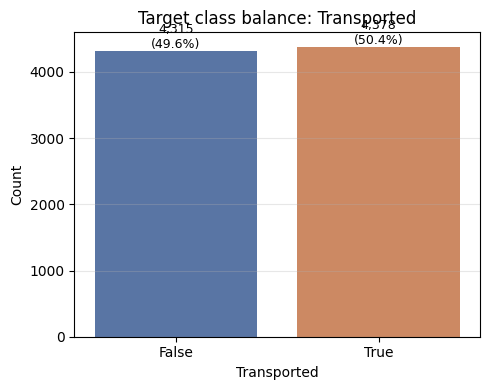

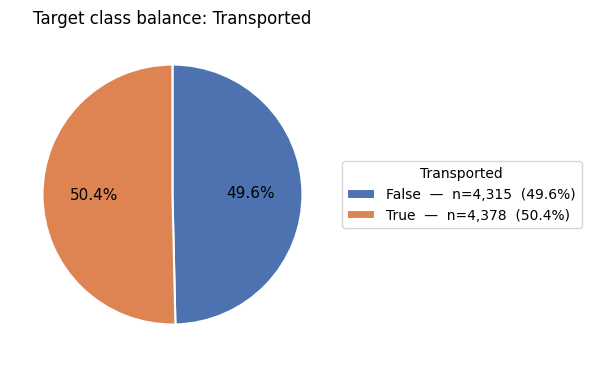

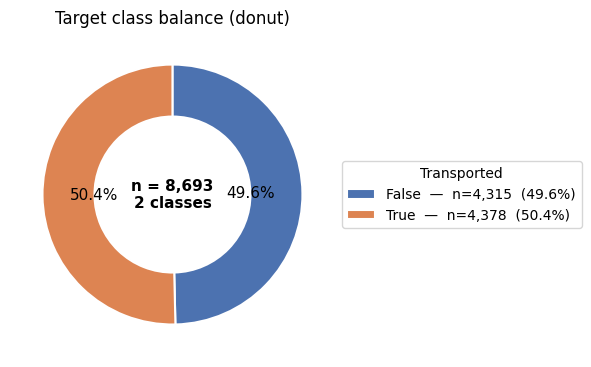

In [21]:
# Print summary
print("\n" + "=" * 70)
print("TARGET DISTRIBUTION IN TRAIN")
print("=" * 70)

counts = train[TARGET].value_counts().sort_index()
props  = train[TARGET].value_counts(normalize=True).sort_index()

print("distribution count:")
print(counts.to_string())
print("\ndistribution percentage:")
print((props * 100).round(3).astype(str) + " %")
print(f"\nTotal samples: {len(train):,}")

fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(
    x=TARGET, data=train, ax=ax,
    hue=TARGET, palette={0: "#4C72B0", 1: "#DD8452"},
    legend=False,
)
ax.set_xticks(range(len(counts)))
ax.set_xticklabels([TARGET_LABELS[k] for k in counts.index])
ax.set_xlabel(TARGET)
ax.set_ylabel("Count")
ax.set_title("Target class balance: Transported")

for i, (k, v) in enumerate(counts.items()):
    ax.text(i, v, f"{v:,}\n({v/len(train)*100:.1f}%)",
            ha="center", va="bottom", fontsize=9)

ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig(f"{PLOT_PATH}/target_balance.png", dpi=130, bbox_inches="tight")
plt.show()
plt.close(fig)

fig, ax = plt.subplots(figsize=(6, 6))
labels = [TARGET_LABELS[k] for k in counts.index]
colors = ["#4C72B0", "#DD8452"]

wedges, texts, autotexts = ax.pie(
    counts.values,
    labels=None,
    autopct=lambda p: f"{p:.1f}%",
    startangle=90,
    counterclock=False,
    colors=colors,
    wedgeprops=dict(edgecolor="white", linewidth=1.5),
    textprops=dict(fontsize=11),
)

legend_labels = [
    f"{TARGET_LABELS[k]}  —  n={counts[k]:,}  ({counts[k]/len(train)*100:.1f}%)"
    for k in counts.index
]
ax.legend(wedges, legend_labels,
          title=TARGET, loc="center left",
          bbox_to_anchor=(1.0, 0.5), fontsize=10)

ax.set_title("Target class balance: Transported", fontsize=12)
ax.set_aspect("equal")
plt.tight_layout()
plt.savefig(f"{PLOT_PATH}/target_balance_pie.png", dpi=130, bbox_inches="tight")
plt.show()
plt.close(fig)

fig, ax = plt.subplots(figsize=(6, 6))
wedges, _, autotexts = ax.pie(
    counts.values,
    labels=None,
    autopct=lambda p: f"{p:.1f}%",
    startangle=90,
    counterclock=False,
    colors=colors,
    wedgeprops=dict(width=0.4, edgecolor="white", linewidth=1.5),
    textprops=dict(fontsize=11),
)

# Balanced 2-class target → show total N in the center, not "majority"
ax.text(0, 0, f"n = {len(train):,}\n2 classes",
        ha="center", va="center", fontsize=11, fontweight="bold")

ax.legend(wedges, legend_labels, title=TARGET,
          loc="center left", bbox_to_anchor=(1.0, 0.5), fontsize=10)
ax.set_title("Target class balance (donut)", fontsize=12)
plt.tight_layout()
plt.savefig(f"{PLOT_PATH}/target_balance_donut.png", dpi=130, bbox_inches="tight")
plt.show()
plt.close(fig)

# Identify column types

In [22]:
num_cols = train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = train.select_dtypes(include=["object", "str", "category"]).columns.tolist()

for c in [ID_COL, TARGET]:
    if c in num_cols:
        num_cols.remove(c)
    if c in cat_cols:
        cat_cols.remove(c)

print("\n" + "=" * 70)
print("COLUMN TYPES")
print("=" * 70)
print(f"Numeric columns ({len(num_cols)}): {num_cols}")
print(f"Categorical/object columns ({len(cat_cols)}): {cat_cols}")


COLUMN TYPES
Numeric columns (6): ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
Categorical/object columns (6): ['HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'VIP', 'Name']


# Numeric feature summary

In [23]:
print("\n" + "=" * 70)
print("NUMERIC SUMMARY - TRAIN")
print("=" * 70)
print(train[num_cols].describe().T)


NUMERIC SUMMARY - TRAIN
               count        mean          std  min   25%   50%   75%      max
Age           8514.0   28.827930    14.489021  0.0  19.0  27.0  38.0     79.0
RoomService   8512.0  224.687617   666.717663  0.0   0.0   0.0  47.0  14327.0
FoodCourt     8510.0  458.077203  1611.489240  0.0   0.0   0.0  76.0  29813.0
ShoppingMall  8485.0  173.729169   604.696458  0.0   0.0   0.0  27.0  23492.0
Spa           8510.0  311.138778  1136.705535  0.0   0.0   0.0  59.0  22408.0
VRDeck        8505.0  304.854791  1145.717189  0.0   0.0   0.0  46.0  24133.0


# Categorical feature summary (unique values / cardinality)

In [24]:
print("\n" + "=" * 70)
print("CATEGORICAL SUMMARY - TRAIN")
print("=" * 70)
for c in cat_cols:
    n_unique = train[c].nunique()
    print(f"\n{c}  (unique values: {n_unique})")
    print(train[c].value_counts(dropna=False))



CATEGORICAL SUMMARY - TRAIN

HomePlanet  (unique values: 3)
HomePlanet
Earth     4602
Europa    2131
Mars      1759
NaN        201
Name: count, dtype: int64

CryoSleep  (unique values: 2)
CryoSleep
False    5439
True     3037
NaN       217
Name: count, dtype: int64

Cabin  (unique values: 6560)
Cabin
NaN         199
G/734/S       8
E/13/S        7
B/11/S        7
C/21/P        7
           ... 
F/1894/P      1
G/1508/P      1
A/98/P        1
G/1499/S      1
G/1500/S      1
Name: count, Length: 6561, dtype: int64

Destination  (unique values: 3)
Destination
TRAPPIST-1e      5915
55 Cancri e      1800
PSO J318.5-22     796
NaN               182
Name: count, dtype: int64

VIP  (unique values: 2)
VIP
False    8291
NaN       203
True      199
Name: count, dtype: int64

Name  (unique values: 8473)
Name
NaN                   200
Elaney Webstephrey      2
Keitha Josey            2
Ankalik Nateansive      2
Gollux Reedall          2
                     ... 
Gravior Noxnuther       1
Kurta Mon

# Check train/test consistency for categorical columns(values in test not seen in train can break some encoders)

## define categorical columns for Spaceship Titanic 

In [28]:
cat_cols = ["HomePlanet", "CryoSleep", "Destination", "VIP"]

for df in (train, test):
    if "Cabin" in df.columns:
        df[["Deck", "CabinNum", "Side"]] = df["Cabin"].str.split("/", expand=True)
        df["CabinNum"] = pd.to_numeric(df["CabinNum"], errors="coerce")

cat_cols += ["Deck", "Side"]


TRAIN vs TEST CATEGORY CONSISTENCY
HomePlanet: only_in_test=none, only_in_train=none
CryoSleep: only_in_test=none, only_in_train=none
Destination: only_in_test=none, only_in_train=none
VIP: only_in_test=none, only_in_train=none
Deck: only_in_test=none, only_in_train=none
Side: only_in_test=none, only_in_train=none


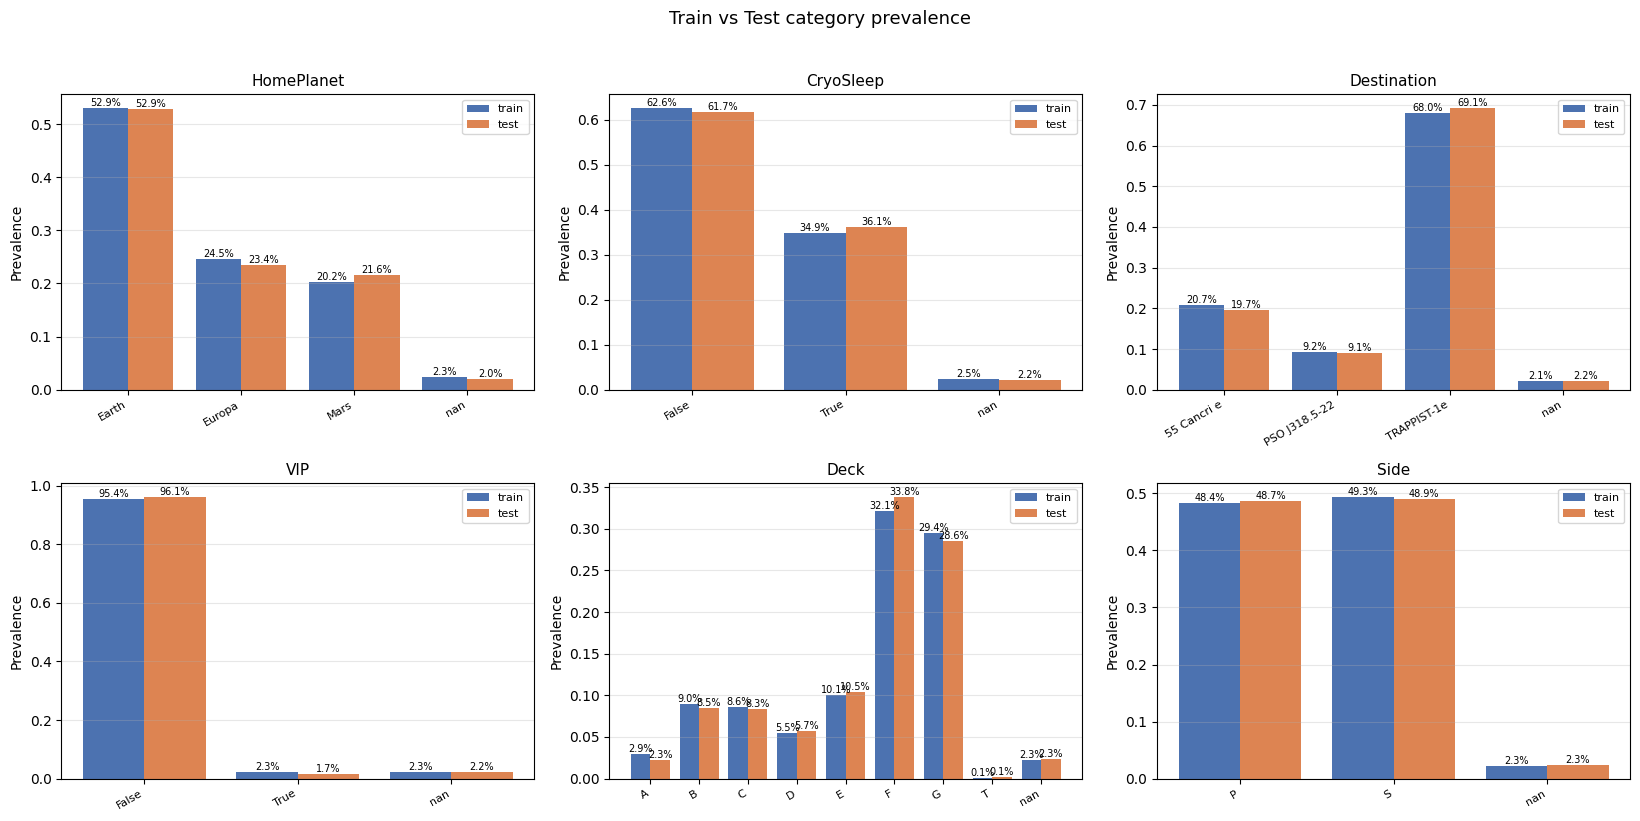

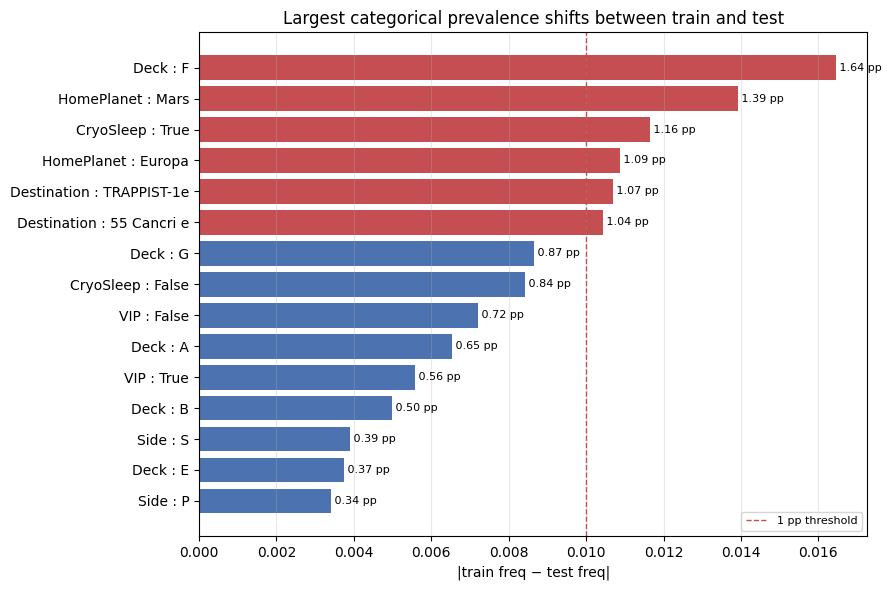

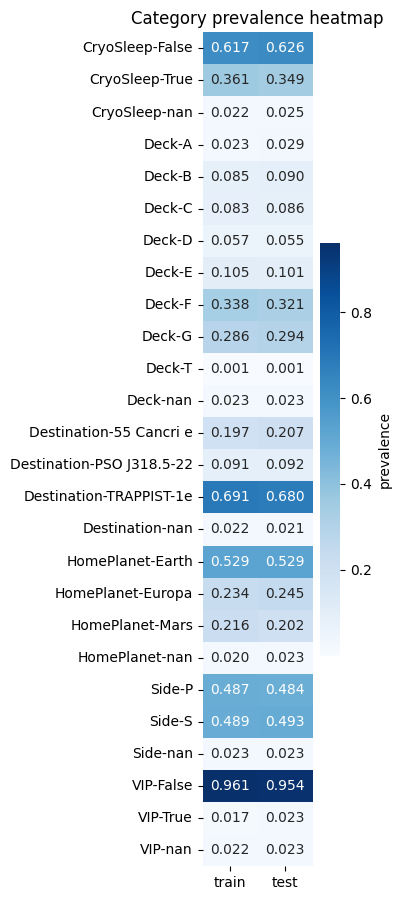


Top 10 category prevalence gaps (train vs test):
    feature    category  train_freq  test_freq  abs_diff
       Deck           F      0.3214     0.3379    0.0164
 HomePlanet        Mars      0.2023     0.2163    0.0139
  CryoSleep        True      0.3494     0.3610    0.0116
 HomePlanet      Europa      0.2451     0.2343    0.0109
Destination TRAPPIST-1e      0.6804     0.6911    0.0107
Destination 55 Cancri e      0.2071     0.1966    0.0104
       Deck           G      0.2944     0.2857    0.0087
  CryoSleep       False      0.6257     0.6173    0.0084
        VIP       False      0.9538     0.9610    0.0072
       Deck           A      0.0294     0.0229    0.0065
        VIP        True      0.0229     0.0173    0.0056
       Deck           B      0.0896     0.0846    0.0050
       Side           S      0.4933     0.4894    0.0039
       Deck           E      0.1008     0.1045    0.0037
       Side           P      0.4838     0.4873    0.0034


In [27]:
# Consistency check + collect stats for plotting
print("\n" + "=" * 70)
print("TRAIN vs TEST CATEGORY CONSISTENCY")
print("=" * 70)

stats_rows = []
for c in cat_cols:
    train_vals = set(train[c].dropna().unique())
    test_vals  = set(test[c].dropna().unique())
    only_in_test  = test_vals - train_vals
    only_in_train = train_vals - test_vals
    print(f"{c}: only_in_test={only_in_test or 'none'}, "
          f"only_in_train={only_in_train or 'none'}")

    # per-category frequency in each split
    tr_freq = train[c].value_counts(normalize=True, dropna=False)
    te_freq = test[c].value_counts(normalize=True,  dropna=False)
    for cat in sorted(set(tr_freq.index) | set(te_freq.index), key=str):
        stats_rows.append({
            "feature":    c,
            "category":   str(cat),
            "train_freq": tr_freq.get(cat, 0.0),
            "test_freq":  te_freq.get(cat, 0.0),
        })

cons_df = pd.DataFrame(stats_rows)

# GROUPED BAR CHART
n_feats = len(cat_cols)
n_cols  = min(3, n_feats)
n_rows  = int(np.ceil(n_feats / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5.5 * n_cols, 4 * n_rows))
axes = np.atleast_1d(axes).ravel()

for ax, c in zip(axes, cat_cols):
    sub = cons_df[cons_df["feature"] == c].copy()
    x = np.arange(len(sub))
    w = 0.4

    ax.bar(x - w/2, sub["train_freq"], w, label="train", color="#4C72B0")
    ax.bar(x + w/2, sub["test_freq"],  w, label="test",  color="#DD8452")

    # label each bar with %
    for xi, v in zip(x - w/2, sub["train_freq"]):
        ax.text(xi, v, f"{v*100:.1f}%", ha="center", va="bottom", fontsize=7)
    for xi, v in zip(x + w/2, sub["test_freq"]):
        ax.text(xi, v, f"{v*100:.1f}%", ha="center", va="bottom", fontsize=7)

    ax.set_xticks(x)
    ax.set_xticklabels(sub["category"], rotation=30, ha="right", fontsize=8)
    ax.set_ylabel("Prevalence")
    ax.set_title(c, fontsize=11)
    ax.grid(alpha=0.3, axis="y")
    ax.legend(fontsize=8)

# hide unused subplots
for ax in axes[n_feats:]:
    ax.axis("off")

plt.suptitle("Train vs Test category prevalence", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f"{PLOT_PATH}/cat_consistency_bars.png", dpi=130, bbox_inches="tight")
plt.show()
plt.close(fig)

# ABSOLUTE DIFFERENCE BAR — sorted by max |Δfrequency|
cons_df["abs_diff"] = (cons_df["train_freq"] - cons_df["test_freq"]).abs()
worst = cons_df.sort_values("abs_diff", ascending=False).head(15).copy()
worst["label"] = worst["feature"] + " : " + worst["category"]

fig, ax = plt.subplots(figsize=(9, 6))
colors = ["#C44E52" if d > 0.01 else "#4C72B0" for d in worst["abs_diff"]]
ax.barh(worst["label"], worst["abs_diff"], color=colors)
ax.invert_yaxis()

for i, v in enumerate(worst["abs_diff"]):
    ax.text(v, i, f" {v*100:.2f} pp", va="center", fontsize=8)

ax.axvline(0.01, color="#C44E52", ls="--", lw=1, label="1 pp threshold")
ax.set_xlabel("|train freq − test freq|")
ax.set_title("Largest categorical prevalence shifts between train and test")
ax.grid(alpha=0.3, axis="x")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(f"{PLOT_PATH}/cat_consistency_diff.png", dpi=130, bbox_inches="tight")
plt.show()
plt.close(fig)

# HEATMAP — all categories × {train, test}
pivot = cons_df.pivot_table(
    index=["feature", "category"], values=["train_freq", "test_freq"]
)
pivot.columns = ["train", "test"]

fig, ax = plt.subplots(figsize=(4, max(4, 0.35 * len(pivot))))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="Blues",
            cbar_kws={"label": "prevalence"}, ax=ax)
ax.set_title("Category prevalence heatmap")
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig(f"{PLOT_PATH}/cat_consistency_heatmap.png", dpi=130, bbox_inches="tight")
plt.show()
plt.close(fig)

# SUMMARY TABLE — worst offenders
print("\nTop 10 category prevalence gaps (train vs test):")
print(worst[["feature", "category", "train_freq", "test_freq", "abs_diff"]]
      .round(4).to_string(index=False))

cons_df.to_csv(f"{PLOT_PATH}/cat_consistency.csv", index=False)

# Distribution plots for numeric features (by target)

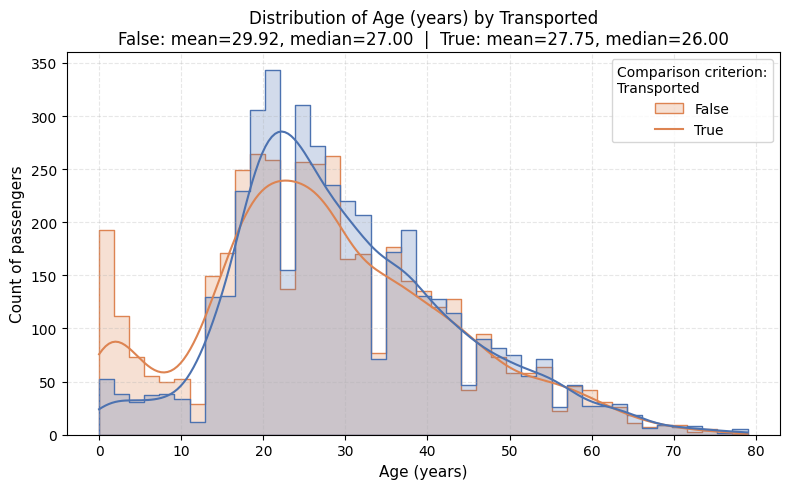

Saved: ./plots\hist_Age_by_Transported.png


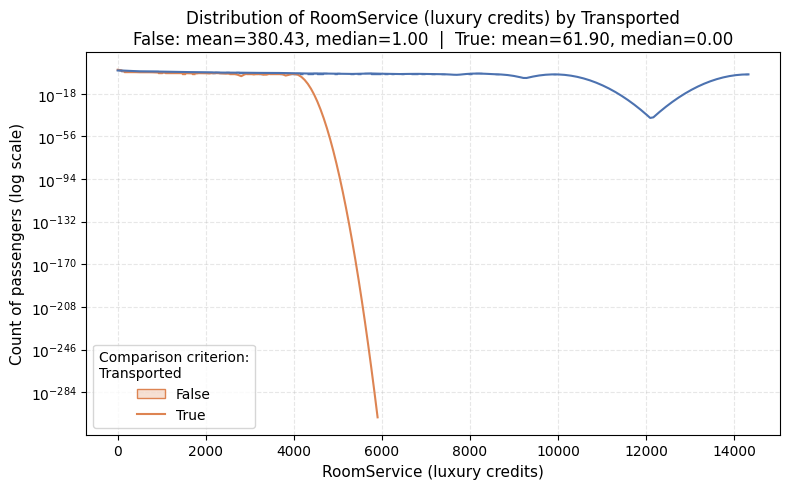

Saved: ./plots\hist_RoomService_by_Transported.png


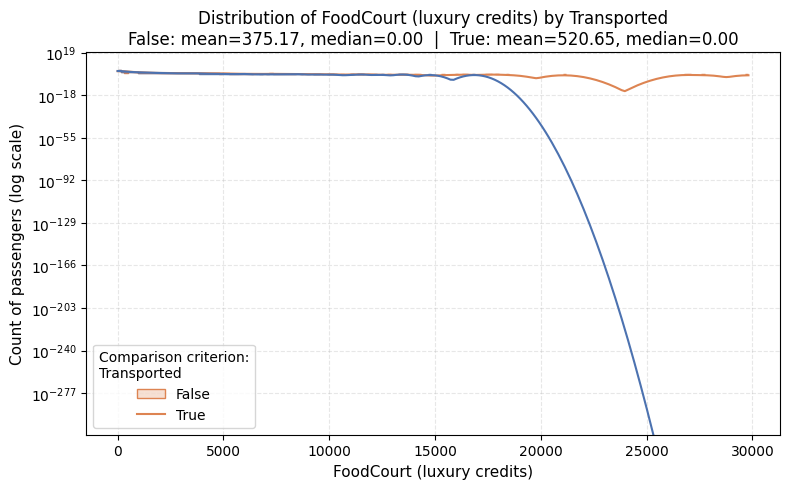

Saved: ./plots\hist_FoodCourt_by_Transported.png


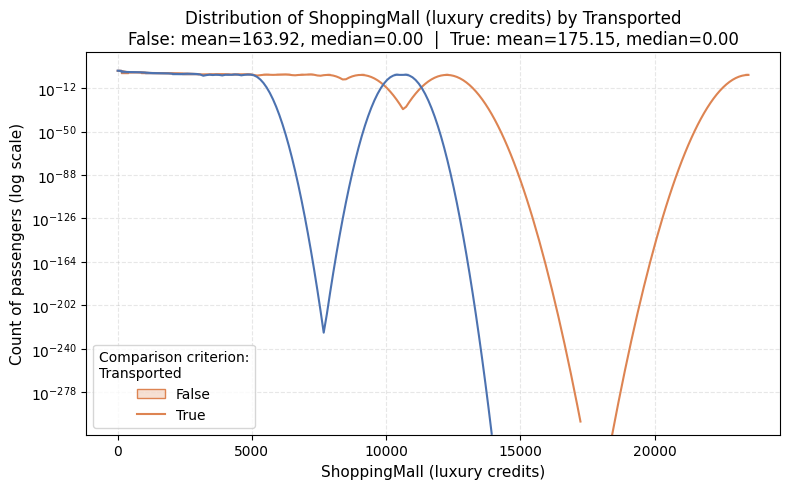

Saved: ./plots\hist_ShoppingMall_by_Transported.png


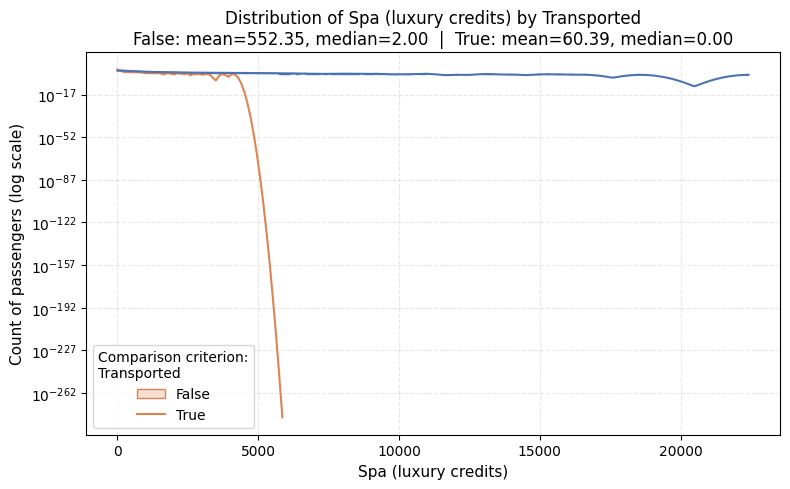

Saved: ./plots\hist_Spa_by_Transported.png


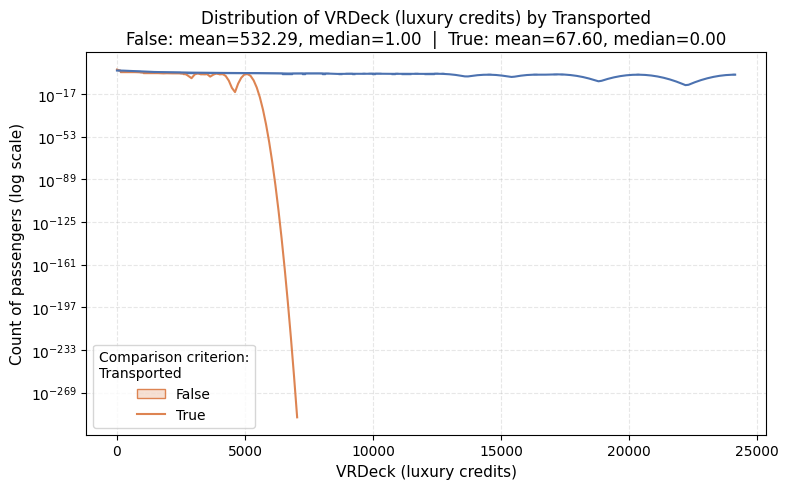

Saved: ./plots\hist_VRDeck_by_Transported.png


In [31]:
UNITS = {
    "Age":          "years",
    "RoomService":  "luxury credits",
    "FoodCourt":    "luxury credits",
    "ShoppingMall": "luxury credits",
    "Spa":          "luxury credits",
    "VRDeck":       "luxury credits",
}

plot_df = train.copy()
for c in num_cols:
    if c != "Age":
        plot_df[c] = plot_df[c].fillna(0)

# One plot per numeric feature
for c in num_cols:
    unit = UNITS.get(c, "")
    unit_str = f" ({unit})" if unit else ""

    # spending columns are heavy-tailed → use log y-axis
    use_log_y = c != "Age"

    fig, ax = plt.subplots(figsize=(8, 5))

    sns.histplot(
        data=plot_df,
        x=c,
        hue=TARGET,
        kde=True,
        element="step",
        stat="count",
        common_norm=False,
        palette={0: "#4C72B0", 1: "#DD8452"},
        log_scale=(False, use_log_y),
        ax=ax,
    )

    ax.set_xlabel(f"{c}{unit_str}", fontsize=11)
    ax.set_ylabel("Count of passengers" + (" (log scale)" if use_log_y else ""),
                  fontsize=11)

    g = plot_df.groupby(TARGET)[c]
    title_stats = "  |  ".join(
        f"{TARGET_LABELS[k]}: mean={g.mean()[k]:.2f}, median={g.median()[k]:.2f}"
        for k in sorted(g.mean().index)
    )
    ax.set_title(
        f"Distribution of {c}{unit_str} by {TARGET}\n{title_stats}",
        fontsize=12,
    )

    leg = ax.legend(
        title=f"Comparison criterion:\n{TARGET}",
        labels=[TARGET_LABELS[k] for k in sorted(TARGET_LABELS)],
        loc="best",
        frameon=True,
    )
    leg.get_title().set_fontsize(10)

    ax.grid(alpha=0.3, linestyle="--")
    plt.tight_layout()

    safe_name = c.replace(" ", "_").replace("/", "_")
    out_file = os.path.join(PLOT_PATH, f"hist_{safe_name}_by_{TARGET}.png")
    plt.savefig(out_file, dpi=130, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    print(f"Saved: {out_file}")

# Categorical vs target (buy rate per category)

In [32]:
print("\n" + "=" * 70)
print("TRANSPORT RATE BY CATEGORY")
print("=" * 70)
for c in cat_cols:
    rate = train.groupby(c)[TARGET].mean().sort_values(ascending=False)
    print(f"\n{c}:")
    print(rate)


TRANSPORT RATE BY CATEGORY

HomePlanet:
HomePlanet
Europa    0.658846
Mars      0.523024
Earth     0.423946
Name: Transported, dtype: float64

CryoSleep:
CryoSleep
True     0.817583
False    0.328921
Name: Transported, dtype: float64

Destination:
Destination
55 Cancri e      0.610000
PSO J318.5-22    0.503769
TRAPPIST-1e      0.471175
Name: Transported, dtype: float64

VIP:
VIP
False    0.506332
True     0.381910
Name: Transported, dtype: float64

Deck:
Deck
B    0.734275
C    0.680054
G    0.516217
A    0.496094
F    0.439871
D    0.433054
E    0.357306
T    0.200000
Name: Transported, dtype: float64

Side:
Side
S    0.555037
P    0.451260
Name: Transported, dtype: float64


# Correlation matrix (numeric features + target)


CORRELATION WITH TARGET (numeric features)
RoomService    -0.244611
Spa            -0.221131
VRDeck         -0.207075
Age            -0.075026
FoodCourt       0.046566
ShoppingMall    0.010141
Name: Transported, dtype: float64


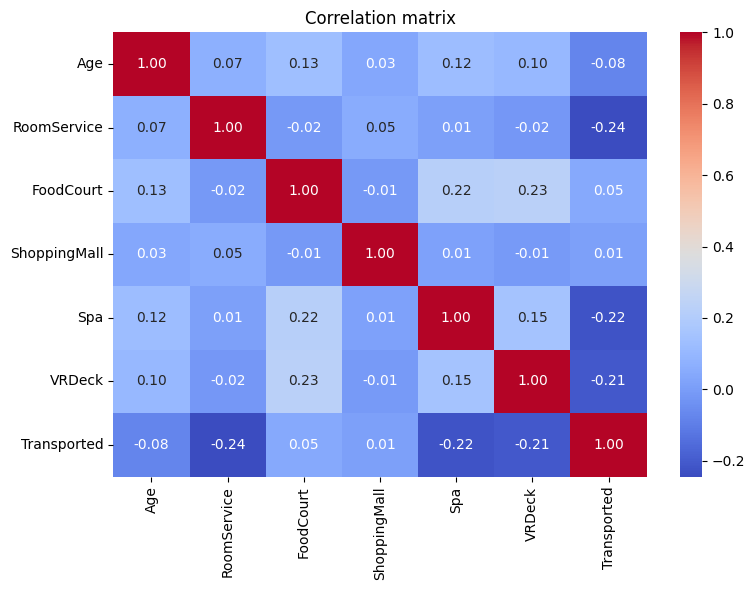

In [33]:
print("\n" + "=" * 70)
print("CORRELATION WITH TARGET (numeric features)")
print("=" * 70)
corr_with_target = train[num_cols + [TARGET]].corr()[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)
print(corr_with_target)

plt.figure(figsize=(8, 6))
sns.heatmap(train[num_cols + [TARGET]].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation matrix")
plt.tight_layout()
plt.savefig(f"{PLOT_PATH}/correlation_matrix.png")
plt.show()
plt.close()


# Outlier check (simple IQR based)

In [34]:
print("\n" + "=" * 70)
print("OUTLIER CHECK (IQR method)")
print("=" * 70)
for c in num_cols:
    q1, q3 = train[c].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_outliers = ((train[c] < lower) | (train[c] > upper)).sum()
    print(f"{c}: {n_outliers} potential outliers "
        f"(bounds: [{lower:.2f}, {upper:.2f}])")


OUTLIER CHECK (IQR method)
Age: 77 potential outliers (bounds: [-9.50, 66.50])
RoomService: 1861 potential outliers (bounds: [-70.50, 117.50])
FoodCourt: 1823 potential outliers (bounds: [-114.00, 190.00])
ShoppingMall: 1829 potential outliers (bounds: [-40.50, 67.50])
Spa: 1788 potential outliers (bounds: [-88.50, 147.50])
VRDeck: 1809 potential outliers (bounds: [-69.00, 115.00])


# FEATURE SUMMARY TABLE

In [35]:
rows = []
for c in num_cols:
    rows.append({
        "feature": c,
        "type": "numeric",
        "n_unique": train[c].nunique(),
        "min": train[c].min(),
        "max": train[c].max(),
        "mean": train[c].mean(),
        "std": train[c].std(),
        "skew": train[c].skew(),
        "kurtosis": train[c].kurtosis(),
        "missing": train[c].isna().sum(),
    })
for c in cat_cols:
    rows.append({
        "feature": c,
        "type": "categorical",
        "n_unique": train[c].nunique(),
        "min": np.nan, "max": np.nan, "mean": np.nan, "std": np.nan,
        "skew": np.nan, "kurtosis": np.nan,
        "missing": train[c].isna().sum(),
    })

summary = pd.DataFrame(rows).sort_values("feature").reset_index(drop=True)
print(summary.to_string(index=False))
summary.to_csv(f"{PLOT_PATH}/feature_summary.csv", index=False)

     feature        type  n_unique  min     max       mean         std      skew   kurtosis  missing
         Age     numeric        80  0.0    79.0  28.827930   14.489021  0.419097   0.101933      179
   CryoSleep categorical         2  NaN     NaN        NaN         NaN       NaN        NaN      217
        Deck categorical         8  NaN     NaN        NaN         NaN       NaN        NaN      199
 Destination categorical         3  NaN     NaN        NaN         NaN       NaN        NaN      182
   FoodCourt     numeric      1507  0.0 29813.0 458.077203 1611.489240  7.102228  73.307230      183
  HomePlanet categorical         3  NaN     NaN        NaN         NaN       NaN        NaN      201
 RoomService     numeric      1273  0.0 14327.0 224.687617  666.717663  6.333014  65.273802      181
ShoppingMall     numeric      1115  0.0 23492.0 173.729169  604.696458 12.627562 328.870913      208
        Side categorical         2  NaN     NaN        NaN         NaN       NaN        NaN

# TARGET RATE BY BINNED NUMERIC FEATURE

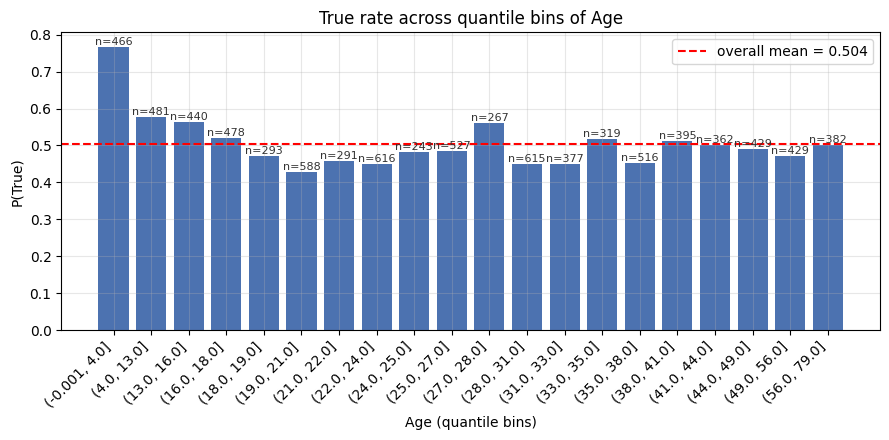


Age:
                 rate  count
bin                         
(-0.001, 4.0]  0.7682    466
(4.0, 13.0]    0.5780    481
(13.0, 16.0]   0.5636    440
(16.0, 18.0]   0.5209    478
(18.0, 19.0]   0.4710    293
(19.0, 21.0]   0.4286    588
(21.0, 22.0]   0.4570    291
(22.0, 24.0]   0.4497    616
(24.0, 25.0]   0.4815    243
(25.0, 27.0]   0.4839    527
(27.0, 28.0]   0.5618    267
(28.0, 31.0]   0.4504    615
(31.0, 33.0]   0.4509    377
(33.0, 35.0]   0.5172    319
(35.0, 38.0]   0.4535    516
(38.0, 41.0]   0.5114    395
(41.0, 44.0]   0.5000    362
(44.0, 49.0]   0.4895    429
(49.0, 56.0]   0.4709    429
(56.0, 79.0]   0.5026    382


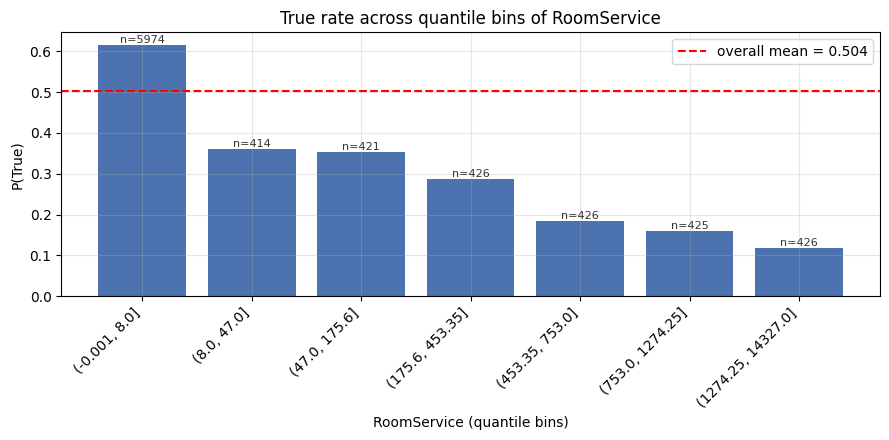


RoomService:
                      rate  count
bin                              
(-0.001, 8.0]       0.6157   5974
(8.0, 47.0]         0.3599    414
(47.0, 175.6]       0.3539    421
(175.6, 453.35]     0.2864    426
(453.35, 753.0]     0.1854    426
(753.0, 1274.25]    0.1600    425
(1274.25, 14327.0]  0.1174    426


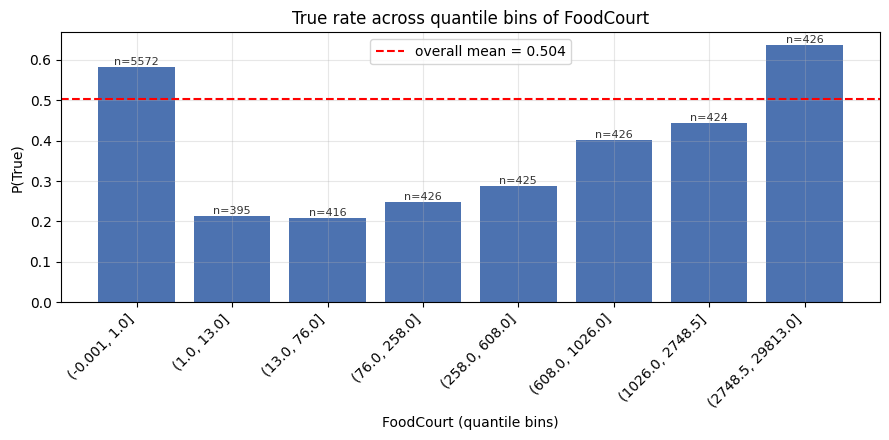


FoodCourt:
                     rate  count
bin                             
(-0.001, 1.0]      0.5833   5572
(1.0, 13.0]        0.2127    395
(13.0, 76.0]       0.2091    416
(76.0, 258.0]      0.2488    426
(258.0, 608.0]     0.2871    425
(608.0, 1026.0]    0.4014    426
(1026.0, 2748.5]   0.4434    424
(2748.5, 29813.0]  0.6362    426


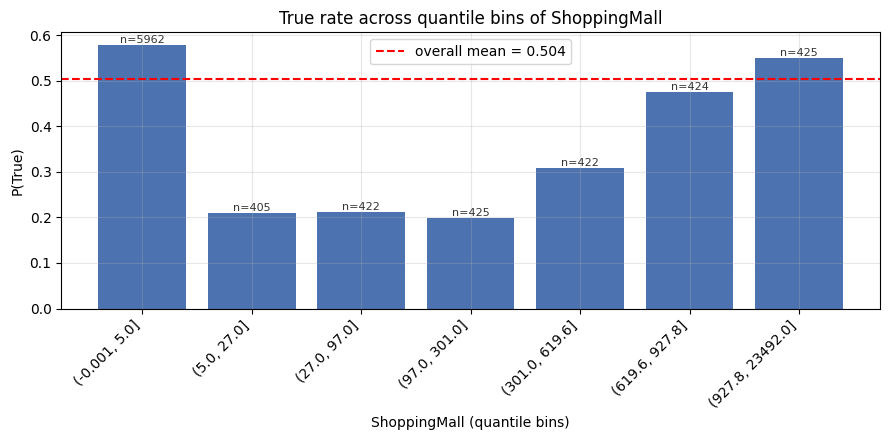


ShoppingMall:
                    rate  count
bin                            
(-0.001, 5.0]     0.5772   5962
(5.0, 27.0]       0.2099    405
(27.0, 97.0]      0.2109    422
(97.0, 301.0]     0.1976    425
(301.0, 619.6]    0.3081    422
(619.6, 927.8]    0.4741    424
(927.8, 23492.0]  0.5506    425


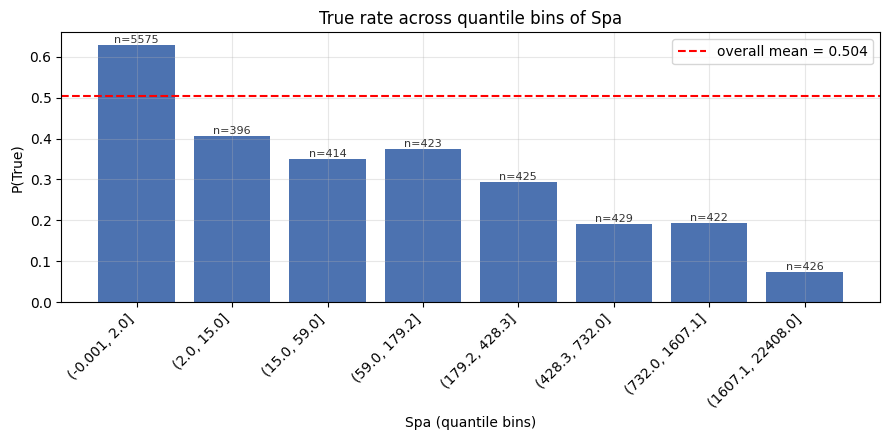


Spa:
                     rate  count
bin                             
(-0.001, 2.0]      0.6282   5575
(2.0, 15.0]        0.4066    396
(15.0, 59.0]       0.3502    414
(59.0, 179.2]      0.3735    423
(179.2, 428.3]     0.2941    425
(428.3, 732.0]     0.1911    429
(732.0, 1607.1]    0.1943    422
(1607.1, 22408.0]  0.0751    426


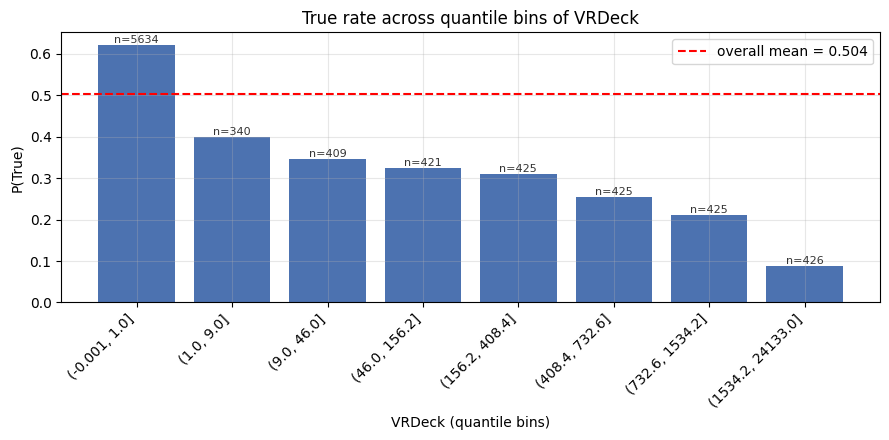


VRDeck:
                     rate  count
bin                             
(-0.001, 1.0]      0.6209   5634
(1.0, 9.0]         0.4000    340
(9.0, 46.0]        0.3472    409
(46.0, 156.2]      0.3254    421
(156.2, 408.4]     0.3106    425
(408.4, 732.6]     0.2541    425
(732.6, 1534.2]    0.2118    425
(1534.2, 24133.0]  0.0869    426

Trend summary (first bin → last bin):
                         Age  0.768 → 0.503  ↓
                 RoomService  0.616 → 0.117  ↓
                   FoodCourt  0.583 → 0.636  ↑
                ShoppingMall  0.577 → 0.551  ↓
                         Spa  0.628 → 0.075  ↓
                      VRDeck  0.621 → 0.087  ↓


In [36]:
N_BINS = 20
bin_rate_tables = {}
overall = train[TARGET].mean()

for c in num_cols:
    tmp = train[[c, TARGET]].dropna(subset=[c]).copy()
    try:
        tmp["bin"] = pd.qcut(tmp[c], q=N_BINS, duplicates="drop")
        binned_by = "quantile"
    except (ValueError, TypeError):
        tmp["bin"] = pd.cut(tmp[c], bins=N_BINS)
        binned_by = "equal-width"

    g = (
        tmp.groupby("bin", observed=True)[TARGET]
        .agg(rate="mean", count="count")
    )
    bin_rate_tables[c] = g

    fig, ax = plt.subplots(figsize=(9, 4.5))
    x = np.arange(len(g))
    bars = ax.bar(x, g["rate"], color="#4C72B0")
    ax.axhline(overall, color="red", ls="--",
               label=f"overall mean = {overall:.3f}")

    for b, cnt in zip(bars, g["count"]):
        ax.annotate(f"n={cnt}", (b.get_x() + b.get_width()/2, b.get_height()),
                    ha="center", va="bottom", fontsize=8, color="#333")

    ax.set_xticks(x)
    ax.set_xticklabels([str(i) for i in g.index], rotation=45, ha="right")
    ax.set_xlabel(f"{c} ({binned_by} bins)")
    ax.set_ylabel(f"P({TARGET_LABELS[1]})")
    ax.set_title(f"{TARGET_LABELS[1]} rate across {binned_by} bins of {c}")
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{PLOT_PATH}/rate_bins_{c}.png", dpi=120, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    print(f"\n{c}:")
    print(g.round(4).to_string())

# trend summary
print("\nTrend summary (first bin → last bin):")
for c, g in bin_rate_tables.items():
    r = g["rate"].values
    arrow = "↑" if r[-1] > r[0] else ("↓" if r[-1] < r[0] else "≈")
    print(f"{c:>28s}  {r[0]:.3f} → {r[-1]:.3f}  {arrow}")

# CATEGORICAL TRANSPORT RATE WITH 95% CI

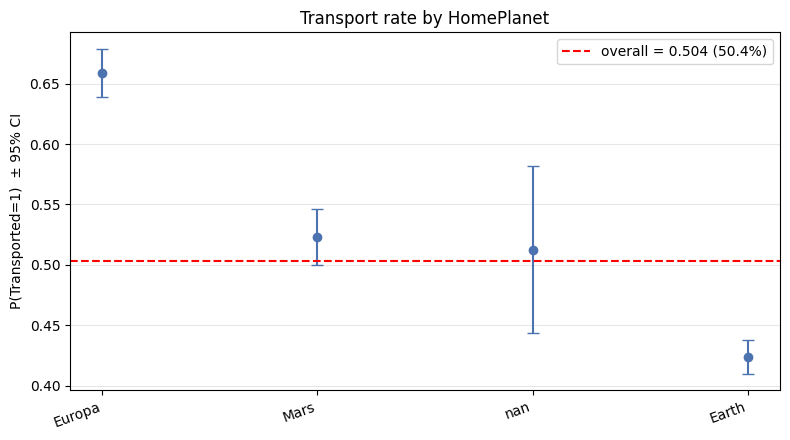


HomePlanet:
              mean  count      se   ci_lo   ci_hi
HomePlanet                                       
Europa      0.6588   2131  0.0103  0.6387  0.6790
Mars        0.5230   1759  0.0119  0.4997  0.5464
NaN         0.5124    201  0.0353  0.4433  0.5815
Earth       0.4239   4602  0.0073  0.4097  0.4382


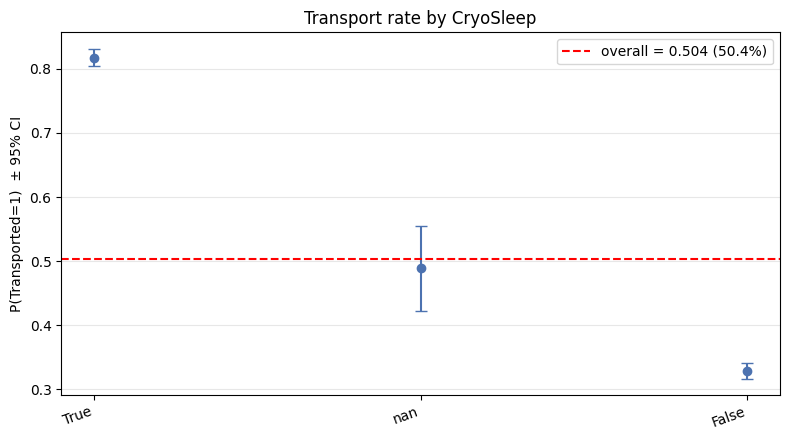


CryoSleep:
             mean  count      se   ci_lo   ci_hi
CryoSleep                                       
True       0.8176   3037  0.0070  0.8038  0.8313
NaN        0.4885    217  0.0339  0.4220  0.5550
False      0.3289   5439  0.0064  0.3164  0.3414


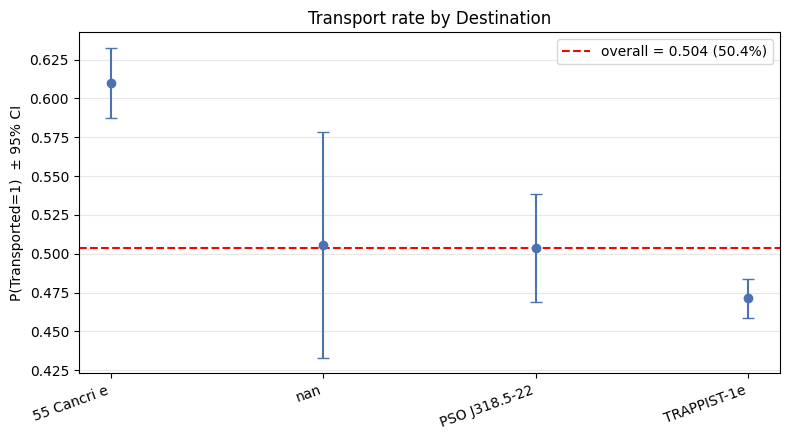


Destination:
                 mean  count      se   ci_lo   ci_hi
Destination                                         
55 Cancri e    0.6100   1800  0.0115  0.5875  0.6325
NaN            0.5055    182  0.0371  0.4329  0.5781
PSO J318.5-22  0.5038    796  0.0177  0.4690  0.5385
TRAPPIST-1e    0.4712   5915  0.0065  0.4585  0.4839


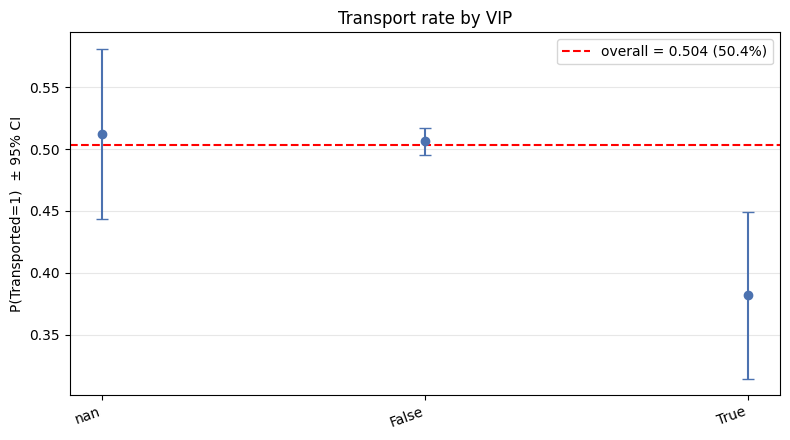


VIP:
         mean  count      se   ci_lo   ci_hi
VIP                                         
NaN    0.5123    203  0.0351  0.4436  0.5811
False  0.5063   8291  0.0055  0.4956  0.5171
True   0.3819    199  0.0344  0.3144  0.4494


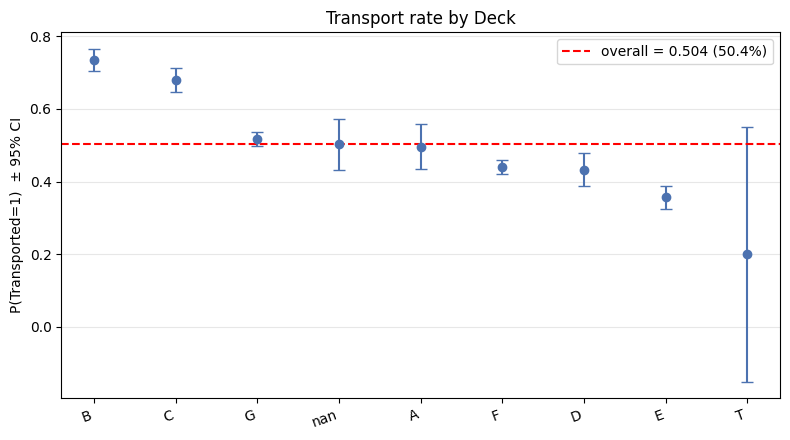


Deck:
        mean  count      se   ci_lo   ci_hi
Deck                                       
B     0.7343    779  0.0158  0.7033  0.7653
C     0.6801    747  0.0171  0.6466  0.7135
G     0.5162   2559  0.0099  0.4969  0.5356
NaN   0.5025    199  0.0354  0.4330  0.5720
A     0.4961    256  0.0312  0.4348  0.5573
F     0.4399   2794  0.0094  0.4215  0.4583
D     0.4331    478  0.0227  0.3886  0.4775
E     0.3573    876  0.0162  0.3256  0.3890
T     0.2000      5  0.1789 -0.1506  0.5506


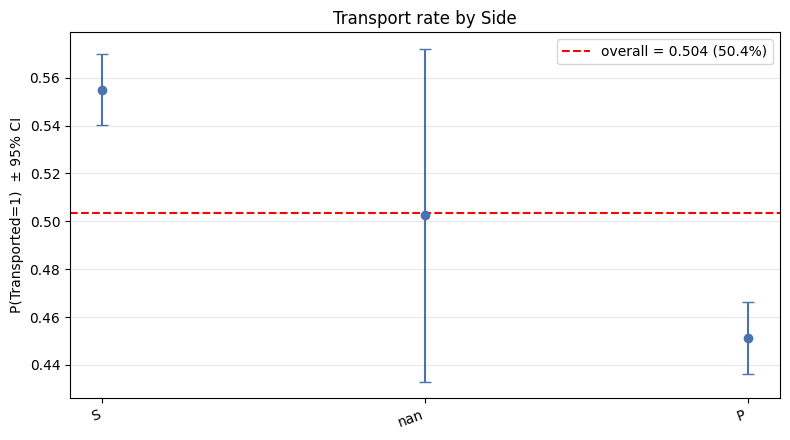


Side:
        mean  count      se   ci_lo   ci_hi
Side                                       
S     0.5550   4288  0.0076  0.5402  0.5699
NaN   0.5025    199  0.0354  0.4330  0.5720
P     0.4513   4206  0.0077  0.4362  0.4663


In [37]:
overall = train[TARGET].mean()
cat_rate_tables = {}

for c in cat_cols:
    # dropna=False so NaN passengers are their own category
    g = train.groupby(c, dropna=False)[TARGET].agg(["mean", "count"])
    g["se"]    = np.sqrt(g["mean"] * (1 - g["mean"]) / g["count"])
    g["ci_lo"] = g["mean"] - 1.96 * g["se"]
    g["ci_hi"] = g["mean"] + 1.96 * g["se"]
    g = g.sort_values("mean", ascending=False)
    cat_rate_tables[c] = g

    fig, ax = plt.subplots(figsize=(8, 4.5))
    x = np.arange(len(g))
    ax.errorbar(x, g["mean"], yerr=1.96 * g["se"],
                fmt="o", capsize=4, color="#4C72B0")
    ax.axhline(overall, color="red", ls="--",
               label=f"overall = {overall:.3f} ({overall*100:.1f}%)")

    ax.set_xticks(x)
    ax.set_xticklabels([str(v) for v in g.index], rotation=20, ha="right")

    ax.set_ylabel(f"P({TARGET}=1)  ± 95% CI")
    ax.set_title(f"Transport rate by {c}")
    ax.legend()
    ax.grid(alpha=0.3, axis="y")
    plt.tight_layout()
    plt.savefig(f"{PLOT_PATH}/transport_rate_cat_{c}.png",
                dpi=120, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    print(f"\n{c}:")
    print(g.round(4))

# CHI-SQUARE TEST OF INDEPENDENCE

In [40]:
from scipy.stats import chi2_contingency

chi_rows = []
for c in cat_cols:
    ct = pd.crosstab(train[c], train[TARGET])
    chi2, p, dof, expected = chi2_contingency(ct)
    # Cramér's V as effect size (0 = no assoc, 1 = perfect)
    n = ct.values.sum()
    cramers_v = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))
    chi_rows.append({
        "feature": c,
        "chi2": chi2,
        "p_value": p,
        "dof": dof,
        "cramers_v": cramers_v,
    })

chi_df = pd.DataFrame(chi_rows).sort_values("cramers_v", ascending=False)
print(chi_df.to_string(index=False))
chi_df.to_csv(f"{PLOT_PATH}/chi_square_results.csv", index=False)

    feature        chi2      p_value  dof  cramers_v
  CryoSleep 1859.612713 0.000000e+00    1   0.468399
       Deck  392.288041 1.074331e-80    7   0.214905
 HomePlanet  324.901383 2.809060e-71    2   0.195601
Destination  106.392157 7.892901e-24    2   0.111806
       Side   91.059597 1.394094e-21    1   0.103540
        VIP   11.542021 6.804065e-04    1   0.036871


# MUTUAL INFORMATION WITH TARGET

CryoSleep             0.11355
Spa                   0.07230
RoomService           0.06817
ShoppingMall          0.06528
VRDeck                0.06280
FoodCourt             0.04004
Deck                  0.02316
HomePlanet            0.01893
Age                   0.01028
Spa__isna             0.00699
Destination           0.00616
VRDeck__isna          0.00574
Side                  0.00527
Age__isna             0.00470
FoodCourt__isna       0.00357
RoomService__isna     0.00118
VIP                   0.00070
ShoppingMall__isna    0.00000


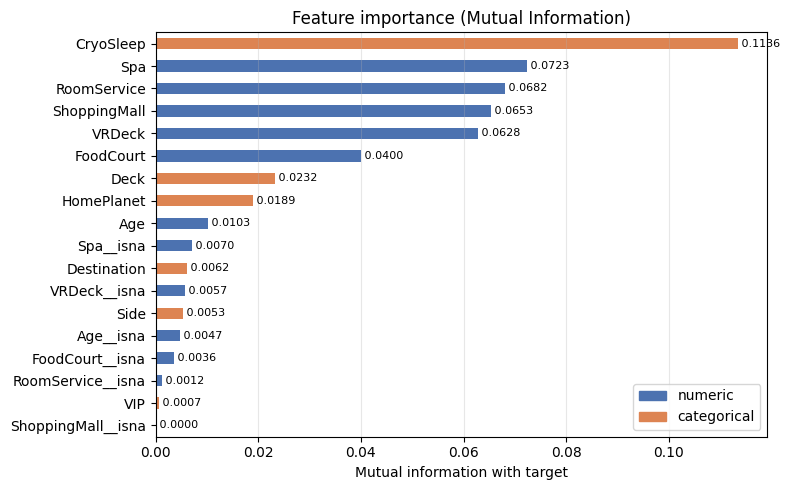

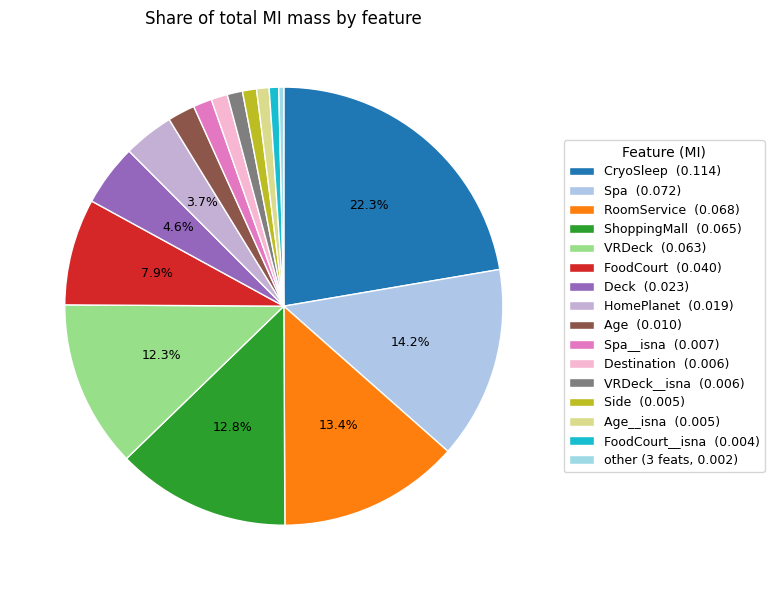

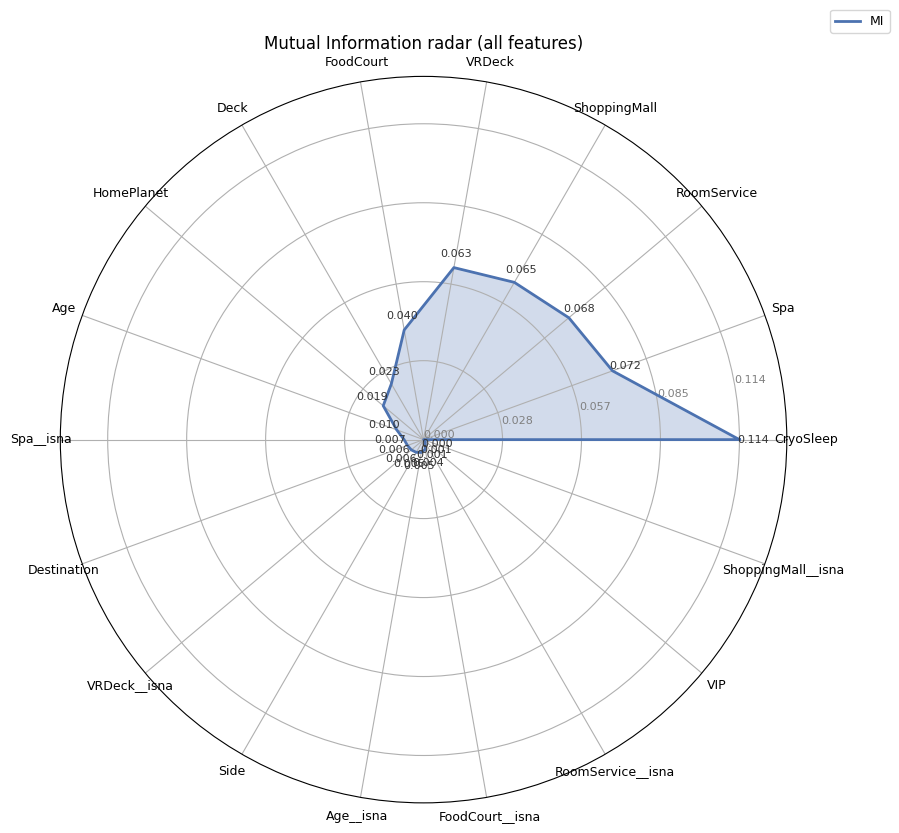

In [41]:
from sklearn.feature_selection import mutual_info_classif

#  MI computation 
X_all = train[num_cols + cat_cols].copy()

for c in num_cols:
    if X_all[c].isna().any():
        X_all[f"{c}__isna"] = X_all[c].isna().astype(int)
        X_all[c] = X_all[c].fillna(X_all[c].median())

for c in cat_cols:
    X_all[c] = X_all[c].fillna("__MISSING__").astype("category").cat.codes

discrete_mask = [c in cat_cols for c in X_all.columns]

y = train[TARGET].values
assert not pd.isna(y).any(), "Target has NaN"

mi = mutual_info_classif(
    X_all, y,
    discrete_features=discrete_mask,
    random_state=42,
)
mi_series = pd.Series(mi, index=X_all.columns).sort_values(ascending=False)
print(mi_series.round(5).to_string())

# BAR CHART (your existing one)
fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#DD8452" if c in cat_cols else "#4C72B0" for c in mi_series.index]
mi_series.plot.barh(ax=ax, color=colors)
ax.invert_yaxis()

for i, v in enumerate(mi_series.values):
    ax.text(v, i, f" {v:.4f}", va="center", fontsize=8)

ax.set_xlabel("Mutual information with target")
ax.set_title("Feature importance (Mutual Information)")
ax.grid(alpha=0.3, axis="x")
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color="#4C72B0", label="numeric"),
    Patch(color="#DD8452", label="categorical"),
], loc="lower right")
plt.tight_layout()
plt.savefig(f"{PLOT_PATH}/mutual_information_bar.png", dpi=120, bbox_inches="tight")
plt.show()
plt.close(fig)

# PIE CHART — share of total MI mass
THRESHOLD = mi_series.sum() * 0.005                                 # features < 0.5% of total → "other"
big   = mi_series[mi_series >= THRESHOLD]
small = mi_series[mi_series <  THRESHOLD]

pie_vals = list(big.values)
pie_lbls = [f"{n}  ({v:.3f})" for n, v in big.items()]
if len(small) > 0:
    pie_vals.append(small.sum())
    pie_lbls.append(f"other ({len(small)} feats, {small.sum():.3f})")

fig, ax = plt.subplots(figsize=(8, 6))
colors = plt.cm.tab20(np.linspace(0, 1, len(pie_vals)))
wedges, _, autotexts = ax.pie(
    pie_vals,
    labels=None,
    autopct=lambda p: f"{p:.1f}%" if p >= 3 else "",
    startangle=90, counterclock=False,
    colors=colors,
    wedgeprops=dict(edgecolor="white", linewidth=1),
    textprops=dict(fontsize=9),
)
ax.legend(wedges, pie_lbls, title="Feature (MI)",
          loc="center left", bbox_to_anchor=(1.0, 0.5), fontsize=9)
ax.set_title("Share of total MI mass by feature", fontsize=12)
plt.tight_layout()
plt.savefig(f"{PLOT_PATH}/mutual_information_pie.png", dpi=130, bbox_inches="tight")
plt.show()
plt.close(fig)

# RADAR CHART — MI profile across features
labels = mi_series.index.tolist()
vals   = mi_series.values
n = len(labels)

angles = np.linspace(0, 2*np.pi, n, endpoint=False).tolist()
angles += angles[:1]
vals_plot = vals.tolist() + [vals[0]]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))
ax.plot(angles, vals_plot, color="#4C72B0", linewidth=2, label="MI")
ax.fill(angles, vals_plot, color="#4C72B0", alpha=0.25)

# annotate each vertex
for ang, v in zip(angles[:-1], vals):
    ax.text(ang, v + 0.005, f"{v:.3f}",
            ha="center", va="center", fontsize=8, color="#333")

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylim(0, max(vals)*1.15)
ax.set_yticks(np.linspace(0, max(vals), 5))
ax.set_yticklabels([f"{v:.3f}" for v in np.linspace(0, max(vals), 5)],
                   fontsize=8, color="gray")
ax.set_rlabel_position(180 / n)
ax.set_title("Mutual Information radar (all features)", fontsize=12, pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.15, 1.10), fontsize=9)
plt.tight_layout()
plt.savefig(f"{PLOT_PATH}/mutual_information_radar.png", dpi=130, bbox_inches="tight")
plt.show()
plt.close(fig)

# FEATURE-FEATURE CORRELATION (numeric only) + VIF

Top correlated numeric pairs:
                             corr
FoodCourt    VRDeck        0.2280
             Spa           0.2219
Spa          VRDeck        0.1538
Age          FoodCourt     0.1304
             Spa           0.1240
             VRDeck        0.1010
             RoomService   0.0687
RoomService  ShoppingMall  0.0545
Age          ShoppingMall  0.0331
RoomService  VRDeck       -0.0196
             FoodCourt    -0.0159
FoodCourt    ShoppingMall -0.0142
ShoppingMall Spa           0.0139
RoomService  Spa           0.0101
ShoppingMall VRDeck       -0.0073

VIF:
FoodCourt       1.105
Spa             1.072
VRDeck          1.069
Age             1.036
RoomService     1.008
ShoppingMall    1.004


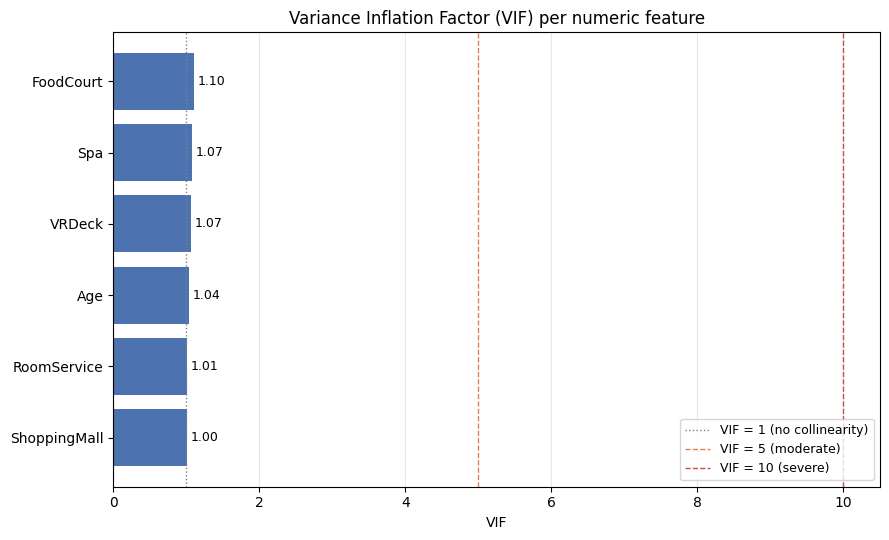

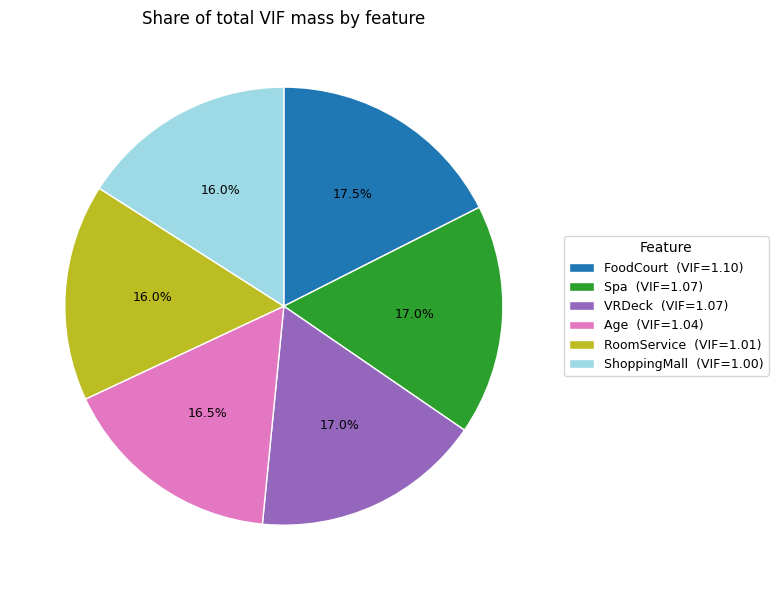

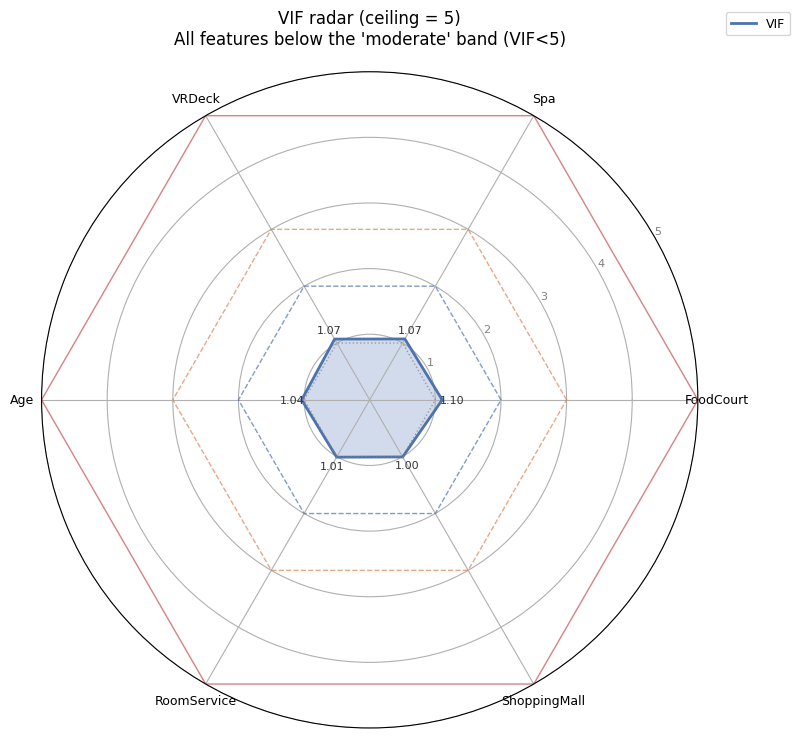

In [44]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# Correlation (unchanged, cleaned up) 
corr = train[num_cols].corr()

mask = np.triu(np.ones(corr.shape), k=1).astype(bool)
pairs = (
    corr.where(mask)
         .stack()
         .rename("corr")
         .to_frame()
         .assign(abs_corr=lambda d: d["corr"].abs())
         .sort_values("abs_corr", ascending=False)
         .drop(columns="abs_corr")
)
print("Top correlated numeric pairs:")
print(pairs.head(15).round(4).to_string())

# VIF (unchanged, NaN-safe) 
sample = train[num_cols].sample(min(50_000, len(train)), random_state=42).copy()
sample = sample.fillna(sample.median(numeric_only=True))
sample = sample.replace([np.inf, -np.inf], np.nan).dropna()

X_vif = add_constant(sample, has_constant="add")
vif = pd.Series(
    [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])],
    index=X_vif.columns,
).drop("const").sort_values(ascending=False)

print("\nVIF:")
print(vif.round(3).to_string())

#  BAR CHART — VIF per feature with severity bands
def vif_color(v):
    if v < 5:   return "#4C72B0"   # fine
    if v < 10:  return "#DD8452"   # watch
    return "#C44E52"               # problem

fig, ax = plt.subplots(figsize=(9, 5.5))
bars = ax.barh(vif.index, vif.values, color=[vif_color(v) for v in vif.values])
ax.invert_yaxis()

# reference lines
ax.axvline(1,  color="gray",    ls=":",  lw=1, label="VIF = 1 (no collinearity)")
ax.axvline(5,  color="#DD8452", ls="--", lw=1, label="VIF = 5 (moderate)")
ax.axvline(10, color="#C44E52", ls="--", lw=1, label="VIF = 10 (severe)")

# value labels
for b, v in zip(bars, vif.values):
    ax.text(v + 0.05, b.get_y() + b.get_height()/2,
            f"{v:.2f}", va="center", fontsize=9)

ax.set_xlabel("VIF")
ax.set_title("Variance Inflation Factor (VIF) per numeric feature")
ax.grid(alpha=0.3, axis="x")
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.savefig(f"{PLOT_PATH}/vif_bar.png", dpi=130, bbox_inches="tight")
plt.show()
plt.close(fig)

#  PIE CHART — share of total VIF mass per feature(shows which features dominate the collinearity "budget")
vif_pos = vif.clip(lower=0)                                 # VIF is always >= 1 in practice, but guard anyway

fig, ax = plt.subplots(figsize=(8, 6))
colors = plt.cm.tab20(np.linspace(0, 1, len(vif_pos)))
wedges, _, autotexts = ax.pie(
    vif_pos.values,
    labels=None,                                            # use legend instead to avoid crowding
    autopct=lambda p: f"{p:.1f}%" if p >= 3 else "",        # hide tiny slices
    startangle=90,
    counterclock=False,
    colors=colors,
    wedgeprops=dict(edgecolor="white", linewidth=1),
    textprops=dict(fontsize=9),
)
ax.legend(
    wedges,
    [f"{name}  (VIF={val:.2f})" for name, val in zip(vif_pos.index, vif_pos.values)],
    title="Feature",
    loc="center left",
    bbox_to_anchor=(1.0, 0.5),
    fontsize=9,
)
ax.set_title("Share of total VIF mass by feature", fontsize=12)
plt.tight_layout()
plt.savefig(f"{PLOT_PATH}/vif_pie.png", dpi=130, bbox_inches="tight")
plt.show()
plt.close(fig)

# Use ceiling=5 so the 1-3 range spreads visibly; cap anything above at 5.
CEIL = 5.0

labels = vif.index.tolist()
values = np.clip(vif.values, 0, CEIL)
n = len(labels)

# angles: close the loop by repeating first point
angles = np.linspace(0, 2 * np.pi, n, endpoint=False).tolist()
angles += angles[:1]
values_plot = values.tolist() + [values[0]]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

# main polygon 
ax.plot(angles, values_plot, color="#4C72B0", linewidth=2, label="VIF")
ax.fill(angles, values_plot, color="#4C72B0", alpha=0.25)

# reference rings for severity 
for ref, color, style in [(1, "gray", ":"), (2, "#4C72B0", "--"),
                          (3, "#DD8452", "--"), (5, "#C44E52", "-")]:
    if ref <= CEIL:
        ax.plot(angles, [ref] * (n + 1), color=color, ls=style,
                lw=1, alpha=0.7)

# tick labels at each feature 
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=9)

# radial grid 
ax.set_ylim(0, CEIL)
ax.set_yticks([1, 2, 3, 4, 5])
ax.set_yticklabels(["1", "2", "3", "4", "5"], fontsize=8, color="gray")
ax.set_rlabel_position(180 / n)  # move radial labels off the first axis

# annotate each vertex with the true VIF value 
for ang, v, true_v in zip(angles[:-1], values, vif.values):
    ax.text(ang, v + 0.15, f"{true_v:.2f}",
            ha="center", va="center", fontsize=8, color="#333")

ax.set_title("VIF radar (ceiling = 5)\nAll features below the 'moderate' band (VIF<5)",
             fontsize=12, pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.15, 1.10), fontsize=9)

plt.tight_layout()
plt.savefig(f"{PLOT_PATH}/vif_radar.png", dpi=130, bbox_inches="tight")
plt.show()
plt.close(fig)

# NUMERIC x CATEGORICAL INTERACTIONS

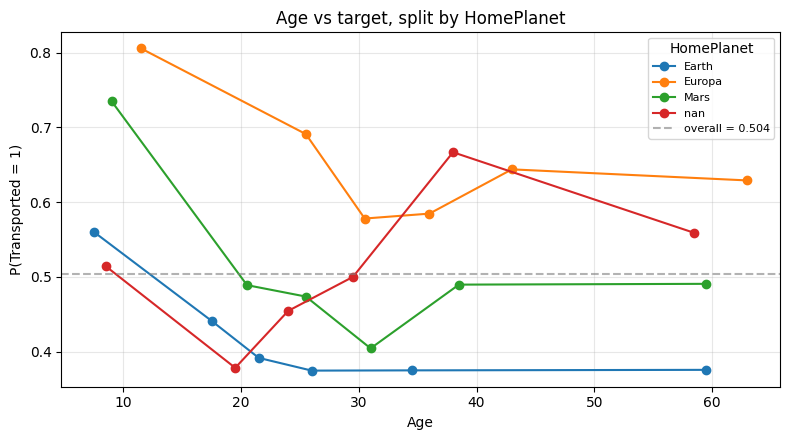

Saved ./plots/interaction_Age_x_HomePlanet.png


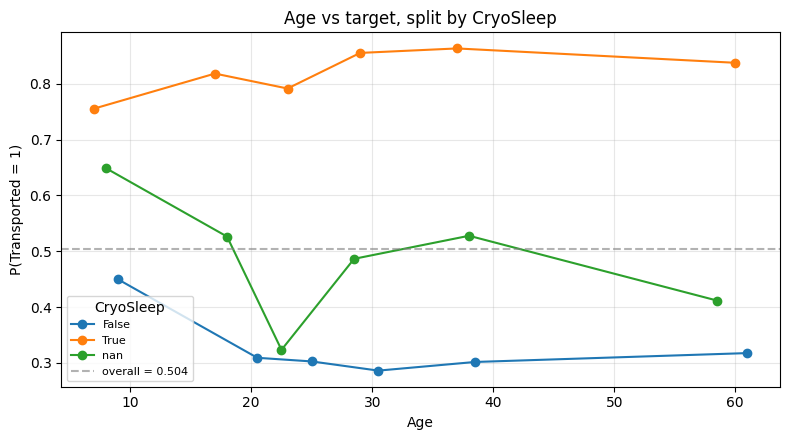

Saved ./plots/interaction_Age_x_CryoSleep.png


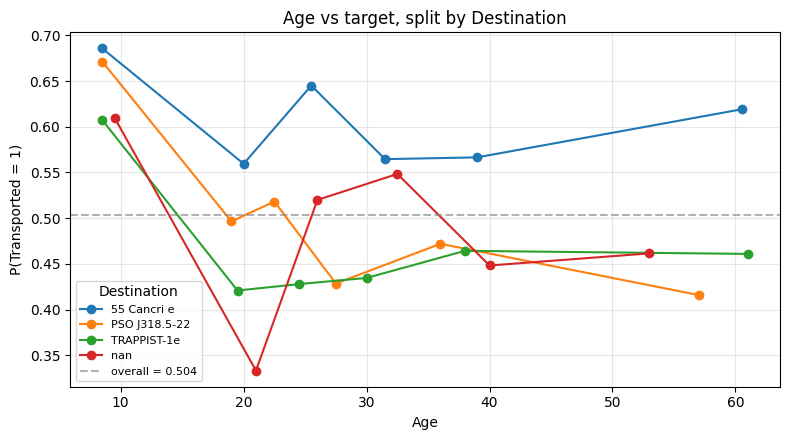

Saved ./plots/interaction_Age_x_Destination.png


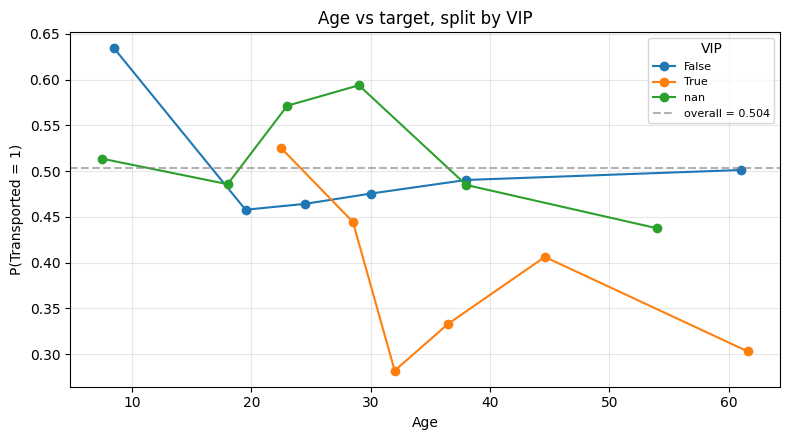

Saved ./plots/interaction_Age_x_VIP.png


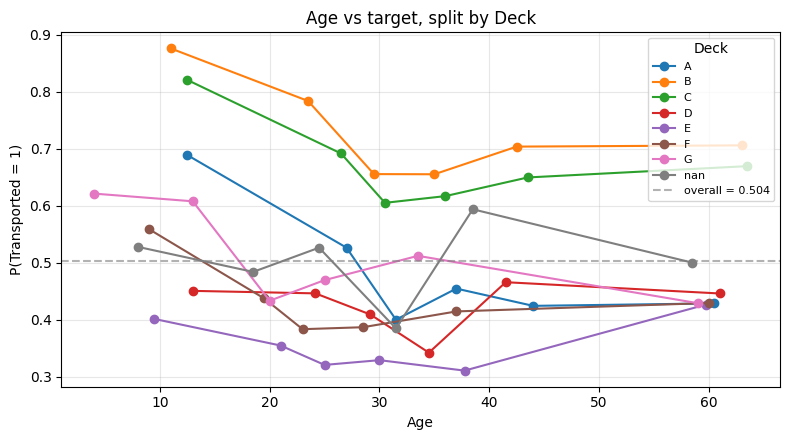

Saved ./plots/interaction_Age_x_Deck.png


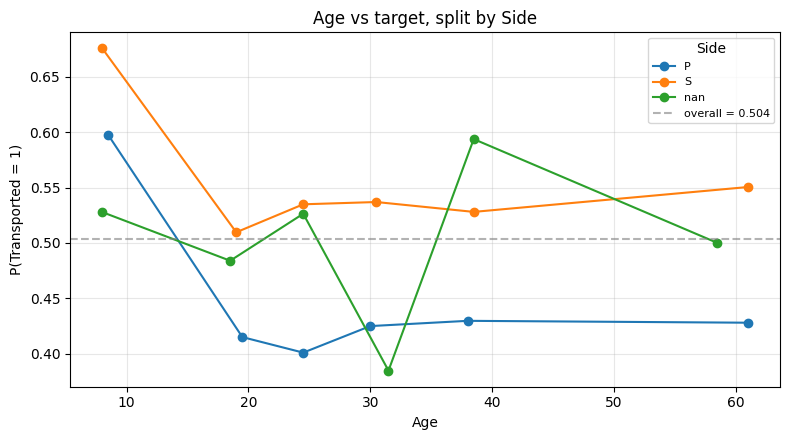

Saved ./plots/interaction_Age_x_Side.png


In [ ]:
strong_numeric = [c for c in mi_series.head(2).index if c == "Age"]
if not strong_numeric:
    strong_numeric = ["Age"]

MIN_GROUP = 30   

for num_c in strong_numeric:
    for cat_c in cat_cols:
        fig, ax = plt.subplots(figsize=(8, 4.5))

        for cat_val, sub in train.groupby(cat_c, dropna=False):
            if len(sub) < MIN_GROUP:
                continue

            try:
                binned = pd.qcut(sub[num_c], q=6, duplicates="drop")
            except (ValueError, TypeError):
                continue

            # attach bin to sub via reset to avoid index-alignment warnings
            tmp = sub[[TARGET]].copy()
            tmp["_bin"] = binned.values
            rate = tmp.groupby("_bin", observed=True)[TARGET].mean()

            # convert interval index to numeric midpoints
            mids = [iv.mid if hasattr(iv, "mid") else np.nan
                    for iv in rate.index]
            if not any(np.isfinite(mids)):
                continue

            ax.plot(mids, rate.values, marker="o",
                    label=str(cat_val), linewidth=1.5)

        ax.axhline(train[TARGET].mean(), color="grey",
                   ls="--", alpha=0.6,
                   label=f"overall = {train[TARGET].mean():.3f}")

        ax.set_xlabel(num_c)
        ax.set_ylabel(f"P({TARGET} = 1)")
        ax.set_title(f"{num_c} vs target, split by {cat_c}")
        ax.legend(title=cat_c, fontsize=8)
        ax.grid(alpha=0.3)

        plt.tight_layout()
        fname = f"{PLOT_PATH}/interaction_{num_c}_x_{cat_c}.png"
        plt.savefig(fname, dpi=110, bbox_inches="tight")
        plt.show()
        plt.close(fig)
        print(f"Saved {fname}")

# PAIRPLOT OF TOP FEATURES

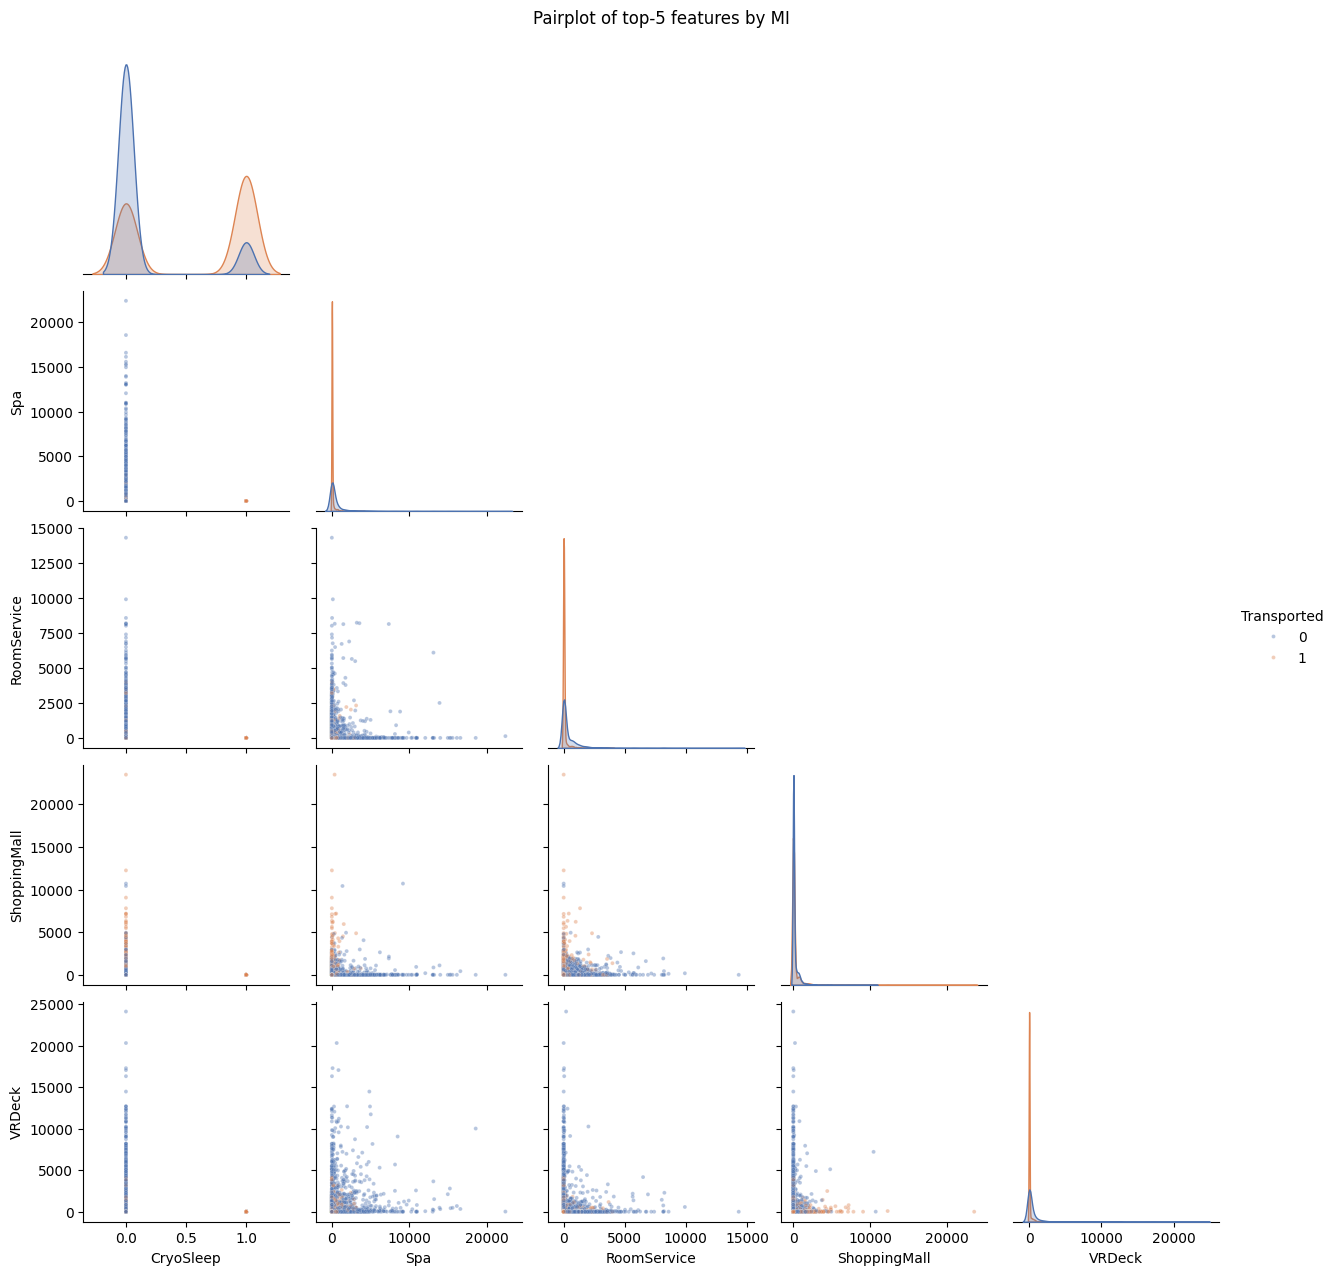

In [46]:
PALETTE = {0: "#4C72B0", 1: "#DD8452"}

top_feats = mi_series.head(5).index.tolist()
sample = train.sample(min(20000, len(train)), random_state=42)

g = sns.pairplot(
    sample[top_feats + [TARGET]],
    hue=TARGET,
    palette=PALETTE,
    corner=True,
    plot_kws={"s": 8, "alpha": 0.4},
    diag_kind="kde",
)
g.fig.suptitle("Pairplot of top-5 features by MI", y=1.02)
g.savefig(f"{PLOT_PATH}/pairplot_top_features.png", dpi=110, bbox_inches="tight")
plt.show()
plt.close()

# TRANSPORT RATE PER SEGMENT (2-way)


HomePlanet x CryoSleep: transport rate
        False   True    nan
Earth   0.321  0.656  0.412
Europa  0.400  0.989  0.655
Mars    0.277  0.912  0.465
nan     0.298  0.867  0.500


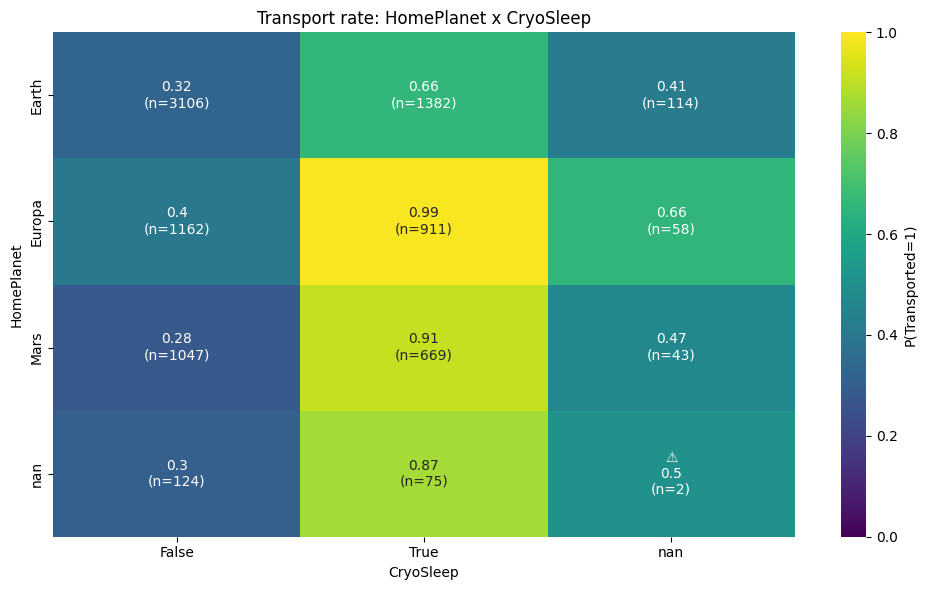


HomePlanet x Destination: transport rate
        55 Cancri e  PSO J318.5-22  TRAPPIST-1e    nan
Earth         0.504          0.499        0.389  0.414
Europa        0.690          0.737        0.635  0.649
Mars          0.611          0.449        0.512  0.595
nan           0.677          0.625        0.467  0.500


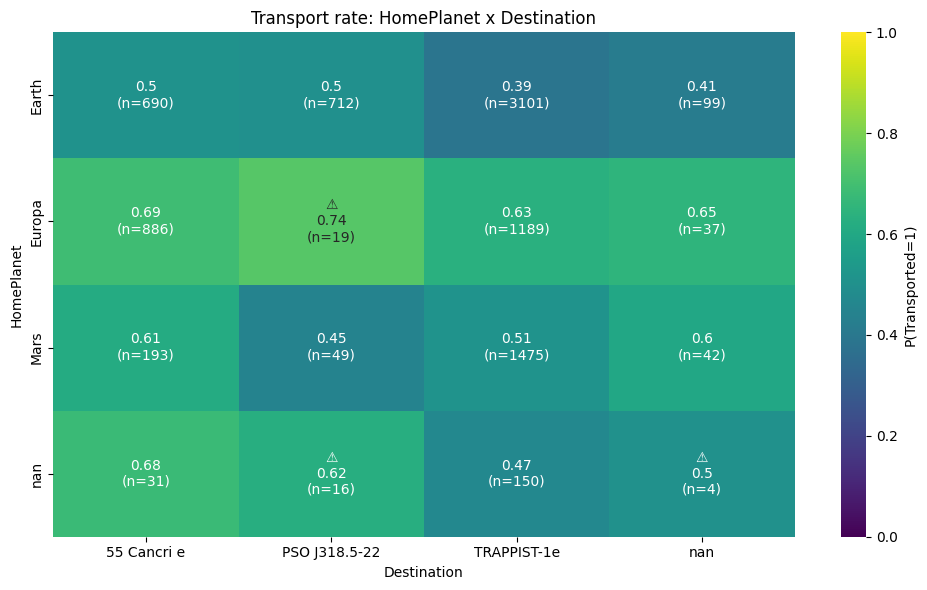


HomePlanet x VIP: transport rate
        False   True    nan
Earth   0.424    NaN  0.409
Europa  0.670  0.489  0.667
Mars    0.534  0.159  0.628
nan     0.513  0.400  0.667


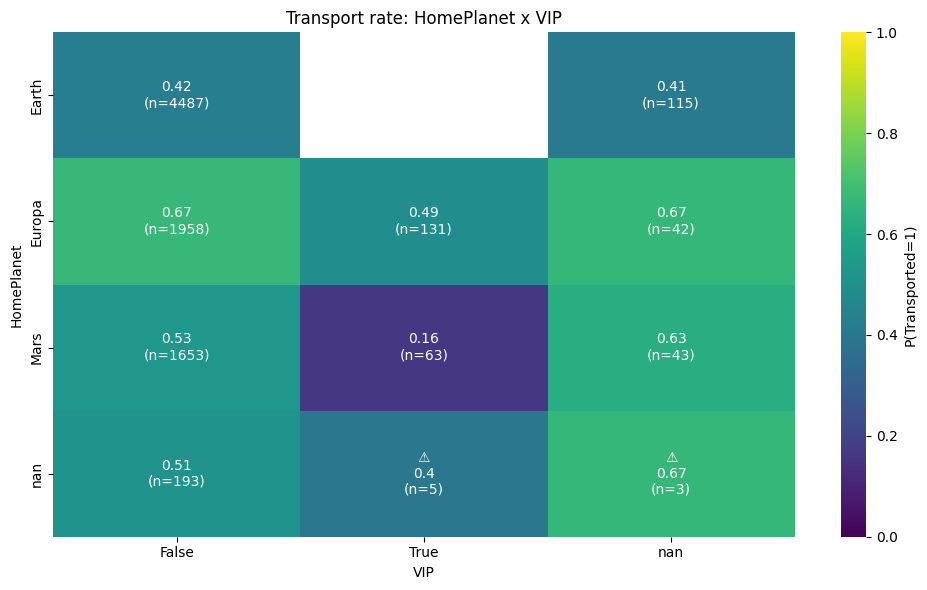


HomePlanet x Deck: transport rate
            A      B      C      D      E      F      G     T    nan
Earth     NaN    NaN    NaN    NaN  0.372  0.292  0.518   NaN  0.400
Europa  0.496  0.734  0.677  0.586  0.547    NaN    NaN  0.25  0.656
Mars      NaN    NaN    NaN  0.333  0.261  0.650    NaN   NaN  0.486
nan     0.500  0.769  0.846  0.400  0.435  0.500  0.443  0.00  0.667


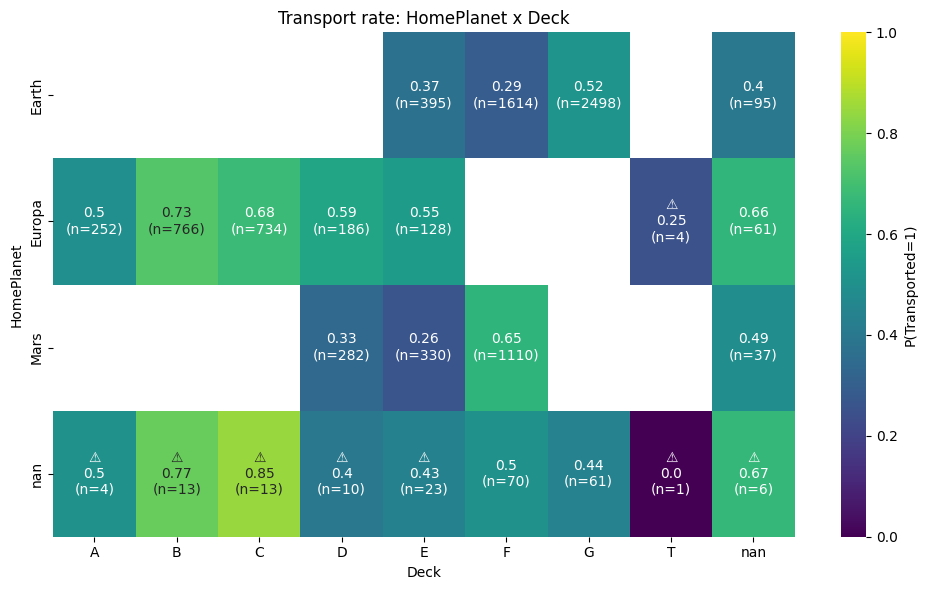


HomePlanet x Side: transport rate
            P      S    nan
Earth   0.369  0.481  0.400
Europa  0.603  0.707  0.656
Mars    0.500  0.549  0.486
nan     0.441  0.569  0.667


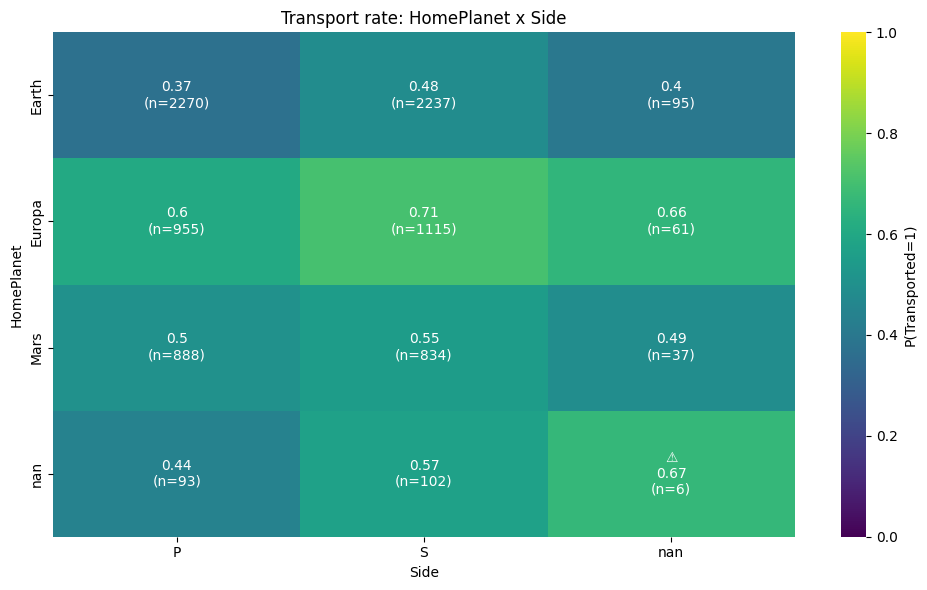


CryoSleep x Destination: transport rate
       55 Cancri e  PSO J318.5-22  TRAPPIST-1e    nan
False        0.381          0.327        0.315  0.338
True         0.928          0.689        0.797  0.938
nan          0.568          0.421        0.467  0.750


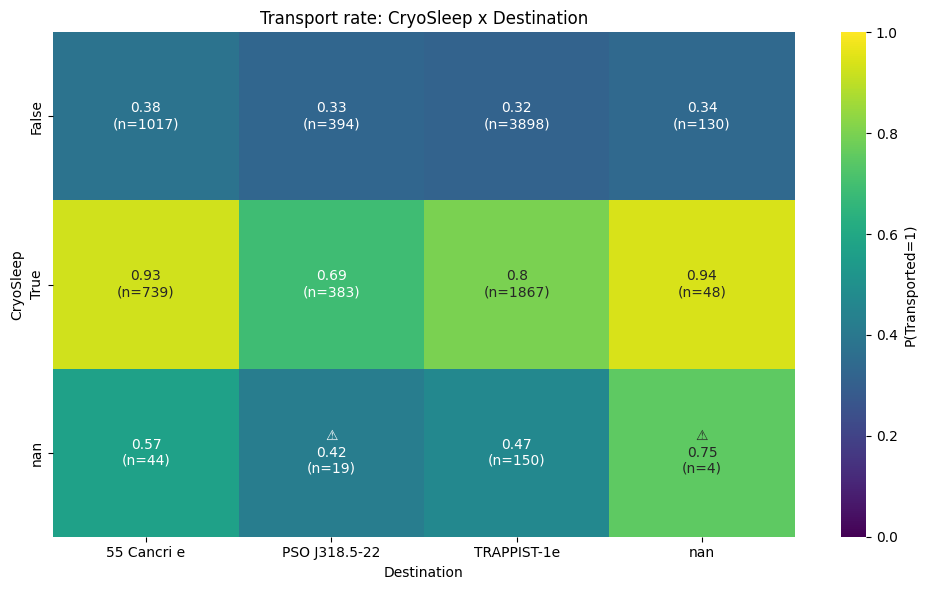


CryoSleep x VIP: transport rate
       False   True    nan
False  0.328  0.309  0.388
True   0.818  1.000  0.747
nan    0.502  0.333  0.143


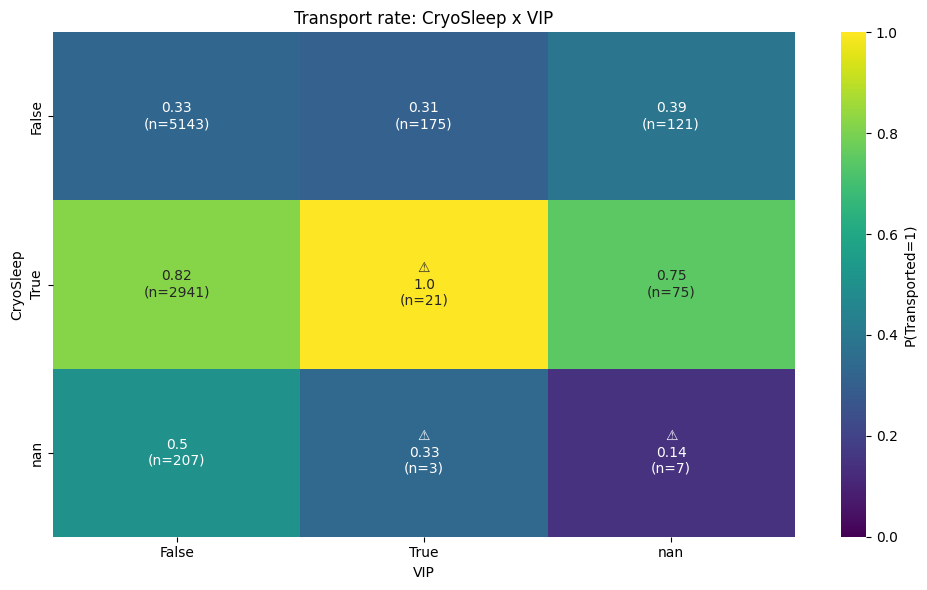


CryoSleep x Deck: transport rate
           A      B      C      D      E      F      G     T    nan
False  0.324  0.422  0.463  0.277  0.286  0.302  0.351  0.25  0.269
True   0.941  0.993  0.993  0.990  0.649  0.985  0.659   NaN  0.798
nan    0.667  0.632  0.739  0.300  0.350  0.441  0.460  0.00  0.571


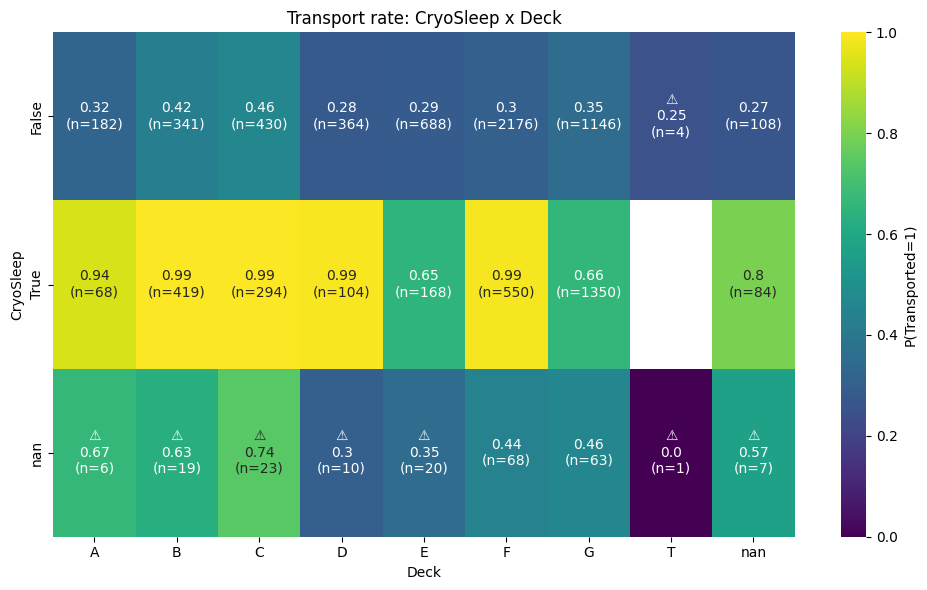


CryoSleep x Side: transport rate
           P      S    nan
False  0.280  0.380  0.269
True   0.779  0.855  0.798
nan    0.381  0.608  0.571


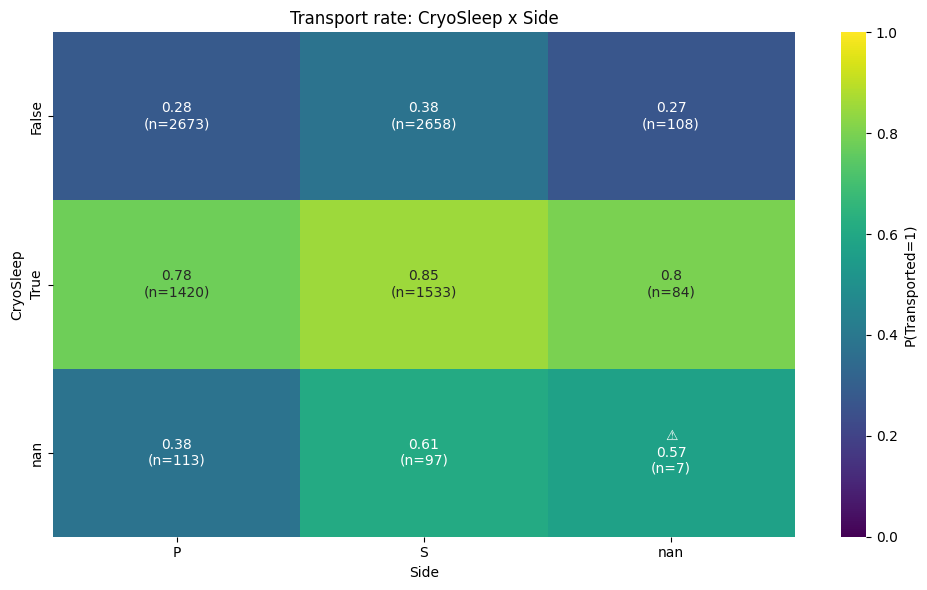


Destination x VIP: transport rate
               False   True    nan
55 Cancri e    0.618  0.415  0.581
PSO J318.5-22  0.507  0.389  0.500
TRAPPIST-1e    0.473  0.368  0.493
nan            0.511  0.000  0.500


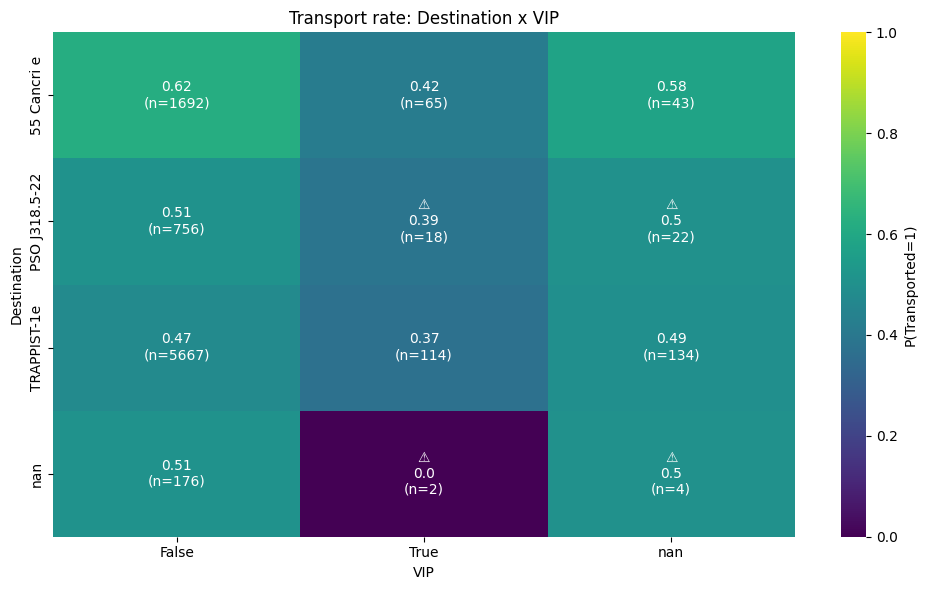


Destination x Deck: transport rate
                   A      B      C      D      E      F      G    T    nan
55 Cancri e    0.537  0.763  0.694  0.611  0.578  0.422  0.630  NaN  0.640
PSO J318.5-22  1.000  0.667  0.769  0.353  0.659  0.282  0.610  NaN  0.278
TRAPPIST-1e    0.458  0.716  0.662  0.379  0.302  0.459  0.467  0.2  0.488
nan            0.500  0.647  0.833  0.400  0.391  0.507  0.467  NaN  0.250


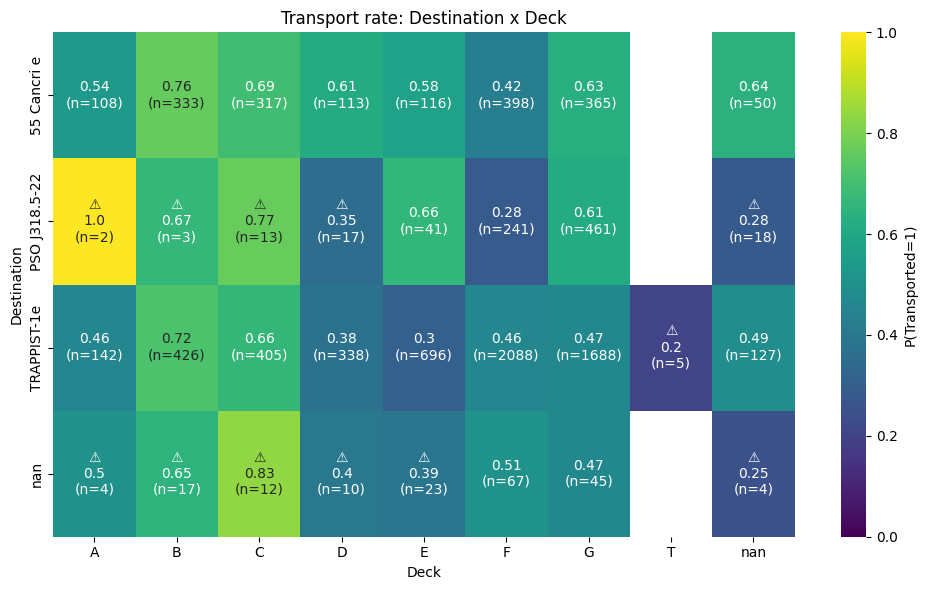


Destination x Side: transport rate
                   P      S    nan
55 Cancri e    0.564  0.651  0.640
PSO J318.5-22  0.486  0.532  0.278
TRAPPIST-1e    0.413  0.528  0.488
nan            0.471  0.549  0.250


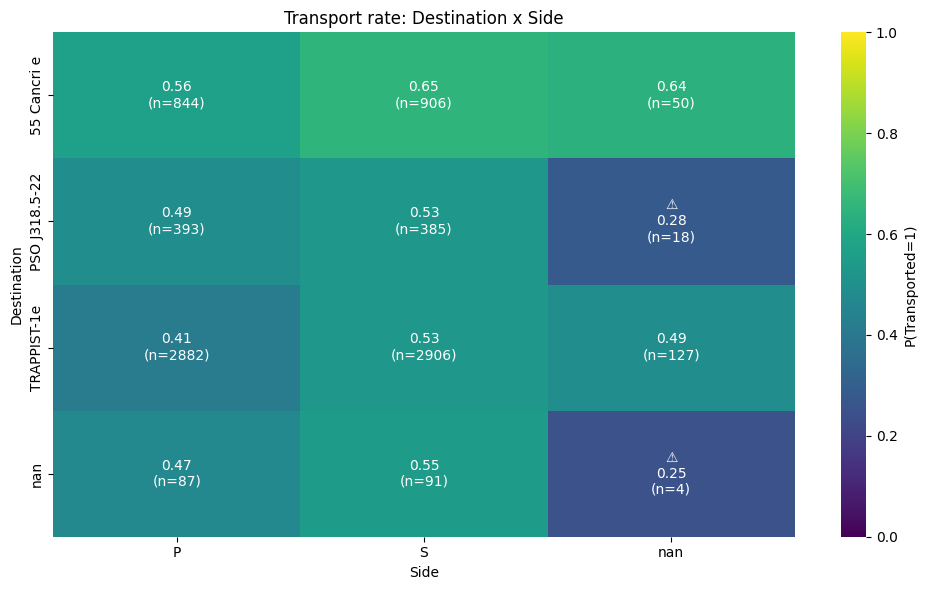


VIP x Deck: transport rate
           A      B      C      D      E      F      G    T    nan
False  0.512  0.746  0.681  0.452  0.361  0.440  0.518  0.2  0.519
True   0.343  0.524  0.634  0.194  0.267  0.172    NaN  NaN  0.167
nan    0.833  0.750  0.737  0.333  0.267  0.543  0.439  NaN  0.333


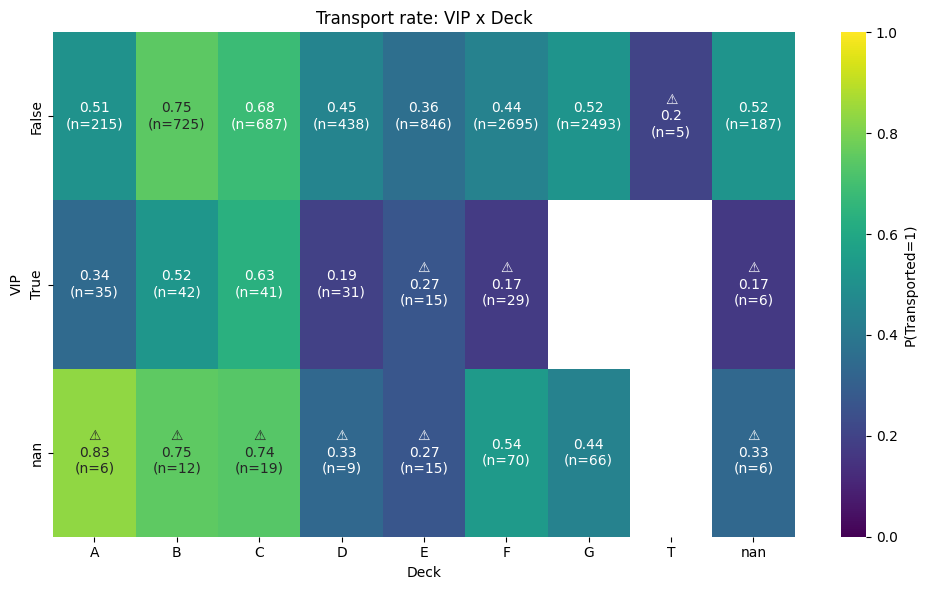


VIP x Side: transport rate
           P      S    nan
False  0.454  0.557  0.519
True   0.294  0.495  0.167
nan    0.495  0.538  0.333


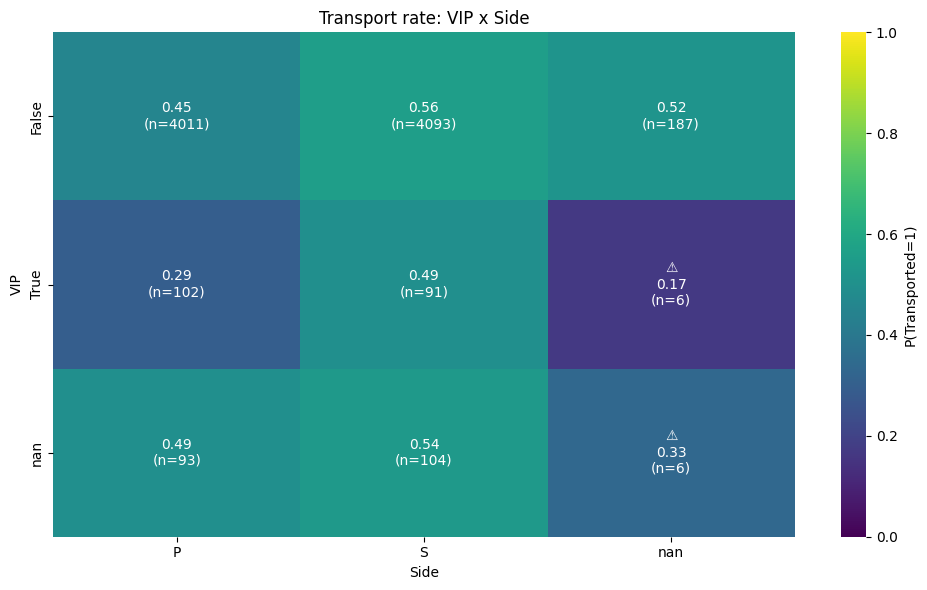


Deck x Side: transport rate
         P      S    nan
A    0.436  0.547    NaN
B    0.674  0.784    NaN
C    0.581  0.764    NaN
D    0.403  0.465    NaN
E    0.343  0.371    NaN
F    0.411  0.471    NaN
G    0.448  0.584    NaN
T    0.250  0.000    NaN
nan    NaN    NaN  0.503


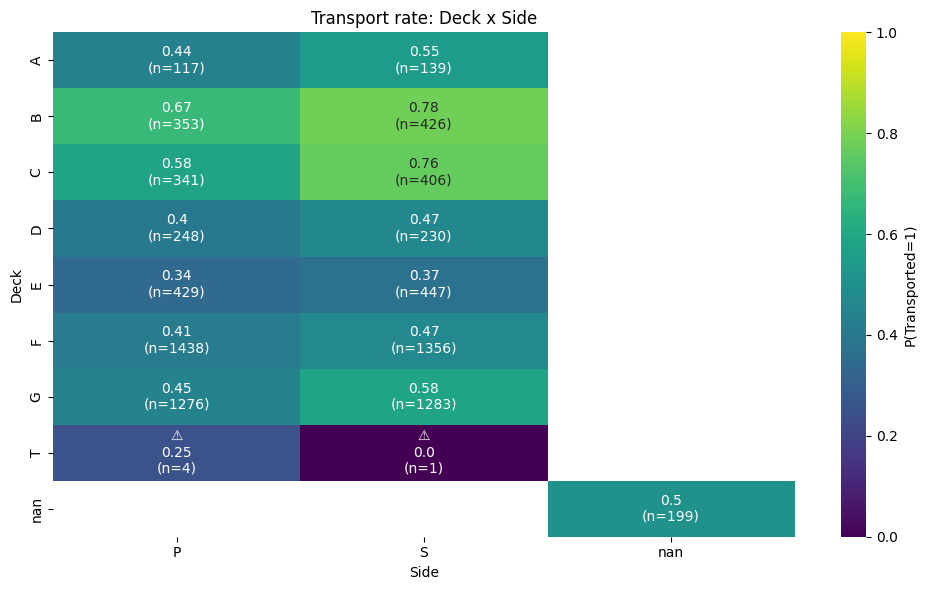

In [48]:
from itertools import combinations

MIN_N = 30   # flag cells smaller than this

for c1, c2 in combinations(cat_cols, 2):
    if "VIP" in (c1, c2) and train["VIP"].sum() < 100:
        print(f"Skipping {c1} x {c2}: VIP group too small")
        continue

    ct_rate = train.pivot_table(
        index=c1, columns=c2, values=TARGET,
        aggfunc="mean", dropna=False,
    )
    ct_cnt = train.pivot_table(
        index=c1, columns=c2, values=TARGET,
        aggfunc="count", dropna=False,
    )

    # string index/columns (handles NaN + booleans cleanly)
    ct_rate.index   = [str(v) for v in ct_rate.index]
    ct_rate.columns = [str(v) for v in ct_rate.columns]
    ct_cnt.index    = [str(v) for v in ct_cnt.index]
    ct_cnt.columns  = [str(v) for v in ct_cnt.columns]

    print(f"\n{c1} x {c2}: transport rate")
    print(ct_rate.round(3))

    # combined annotation: "rate (n=count)"
    annot = ct_rate.round(2).astype(str) + "\n(n=" + ct_cnt.fillna(0).astype(int).astype(str) + ")"
    # flag small cells
    annot = annot.where(ct_cnt >= MIN_N, "⚠\n" + annot)

    fig, ax = plt.subplots(figsize=(10, 6))
    sns.heatmap(
        ct_rate, annot=annot, fmt="", cmap="viridis",
        vmin=0, vmax=1, ax=ax,
        cbar_kws={"label": f"P({TARGET}=1)"},
    )
    ax.set_title(f"Transport rate: {c1} x {c2}")
    ax.set_xlabel(c2)
    ax.set_ylabel(c1)
    plt.tight_layout()
    plt.savefig(f"{PLOT_PATH}/heatmap_{c1}_x_{c2}.png",
                dpi=110, bbox_inches="tight")
    plt.show()
    plt.close(fig)

# MANN-WHITNEY U TEST

In [50]:
from scipy.stats import mannwhitneyu

mw_rows = []
for c in num_cols:
    # drop NaNs per column — Mann-Whitney needs finite values
    a = train.loc[train[TARGET] == 1, c].dropna()
    b = train.loc[train[TARGET] == 0, c].dropna()

    if len(a) < 2 or len(b) < 2:
        print(f"Skipping {c}: too few non-NaN values")
        continue

    stat, p = mannwhitneyu(a, b, alternative="two-sided")
    n1, n2 = len(a), len(b)
    rbc = 1 - (2 * stat) / (n1 * n2)

    mw_rows.append({
        "feature":       c,
        "U":             stat,
        "p_value":       p,
        "rank_biserial": rbc,
        "median_yes":    a.median(),
        "median_no":     b.median(),
        "n_yes":         n1,
        "n_no":          n2,
    })

mw_df = (pd.DataFrame(mw_rows)
           .sort_values("rank_biserial", key=np.abs, ascending=False))

print(mw_df.to_string(index=False))
mw_df.to_csv(f"{PLOT_PATH}/mannwhitney_results.csv", index=False)

     feature         U       p_value  rank_biserial  median_yes  median_no  n_yes  n_no
         Spa 5667783.0 7.445560e-259       0.373864         0.0        4.0   4287  4223
 RoomService 5765800.5 6.654092e-257       0.363318         0.0        1.0   4295  4217
      VRDeck 5898194.0 1.547741e-231       0.347653         0.0        1.0   4280  4225
ShoppingMall 6991589.5  2.194837e-98       0.223085         0.0        0.0   4264  4221
   FoodCourt 7373447.0  8.880364e-67       0.185455         0.0        0.0   4279  4231
         Age 8317627.0  5.619032e-11       0.081995        26.0       27.0   4288  4226


# TARGET ENCODING PREVIEW (with smoothing)

In [51]:
prior = train[TARGET].mean()
k = 20  # smoothing factor

for c in cat_cols:
    g = train.groupby(c)[TARGET].agg(["mean", "count"])
    g["smoothed"] = (g["count"] * g["mean"] + k * prior) / (g["count"] + k)
    g = g.sort_values("smoothed", ascending=False)
    print(f"\n{c} target encoding (smoothed, k={k}):")
    print(g.round(4))


HomePlanet target encoding (smoothed, k=20):
              mean  count  smoothed
HomePlanet                         
Europa      0.6588   2131    0.6574
Mars        0.5230   1759    0.5228
Earth       0.4239   4602    0.4243

CryoSleep target encoding (smoothed, k=20):
             mean  count  smoothed
CryoSleep                         
True       0.8176   3037    0.8155
False      0.3289   5439    0.3296

Destination target encoding (smoothed, k=20):
                 mean  count  smoothed
Destination                           
55 Cancri e    0.6100   1800    0.6088
PSO J318.5-22  0.5038    796    0.5038
TRAPPIST-1e    0.4712   5915    0.4713

VIP target encoding (smoothed, k=20):
         mean  count  smoothed
VIP                           
False  0.5063   8291    0.5063
True   0.3819    199    0.3930

Deck target encoding (smoothed, k=20):
        mean  count  smoothed
Deck                         
B     0.7343    779    0.7285
C     0.6801    747    0.6755
G     0.5162   2559    0

# USELESS FEATURE DETECTION

In [52]:
report = []
for c in num_cols + cat_cols:
    nunique = train[c].nunique(dropna=False)
    top_share = train[c].value_counts(normalize=True, dropna=False).iloc[0]
    report.append({
        "feature": c,
        "nunique": nunique,
        "top_value_share": round(top_share, 4),
        "is_constant": nunique == 1,
        "is_near_constant": top_share > 0.99,
    })
print(pd.DataFrame(report).to_string(index=False))

     feature  nunique  top_value_share  is_constant  is_near_constant
         Age       81           0.0373        False             False
 RoomService     1274           0.6416        False             False
   FoodCourt     1508           0.6276        False             False
ShoppingMall     1116           0.6427        False             False
         Spa     1328           0.6124        False             False
      VRDeck     1307           0.6321        False             False
  HomePlanet        4           0.5294        False             False
   CryoSleep        3           0.6257        False             False
 Destination        4           0.6804        False             False
         VIP        3           0.9538        False             False
        Deck        9           0.3214        False             False
        Side        3           0.4933        False             False


# TRAIN/TEST DISTRIBUTION SHIFT (KS TEST)

     feature  KS_stat  p_value
         Age      NaN      NaN
 RoomService      NaN      NaN
   FoodCourt      NaN      NaN
ShoppingMall      NaN      NaN
         Spa      NaN      NaN
      VRDeck      NaN      NaN


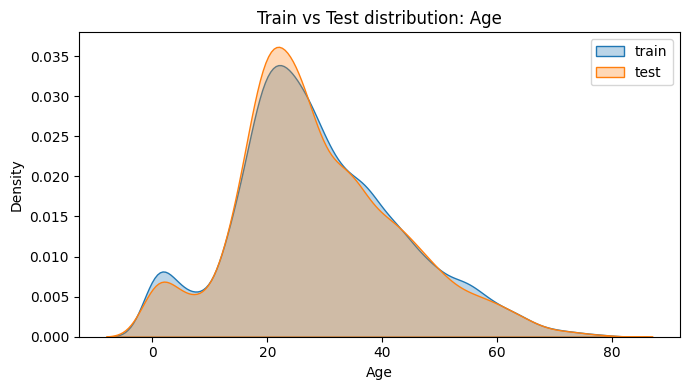

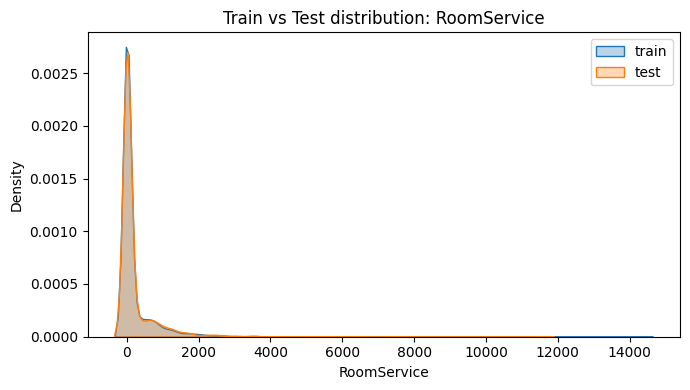

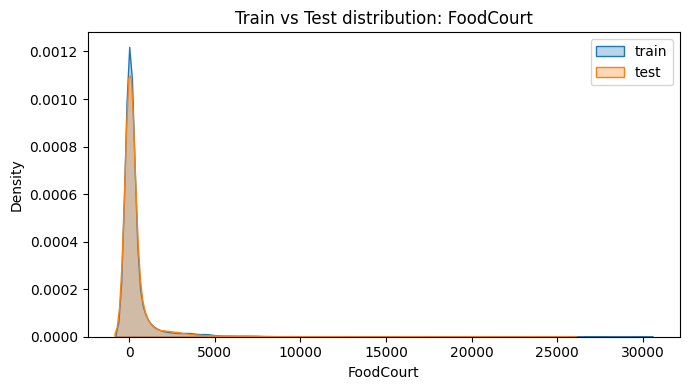

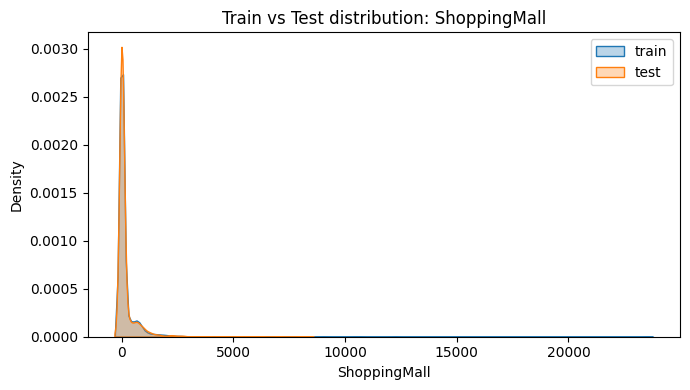

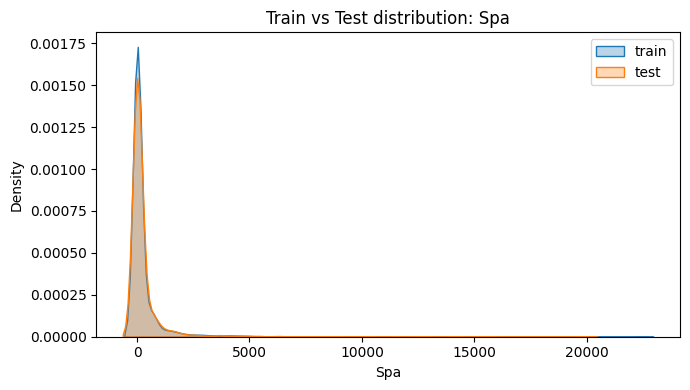

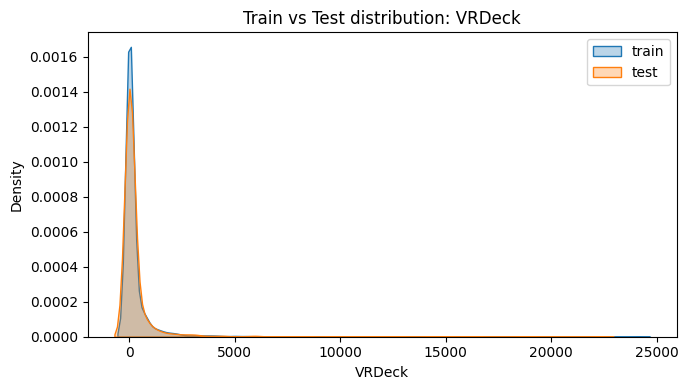

In [53]:
from scipy.stats import ks_2samp

shift_rows = []
for c in num_cols:
    stat, p = ks_2samp(train[c], test[c])
    shift_rows.append({"feature": c, "KS_stat": stat, "p_value": p})

shift_df = pd.DataFrame(shift_rows).sort_values("KS_stat", ascending=False)
print(shift_df.to_string(index=False))

for c in num_cols:
    fig, ax = plt.subplots(figsize=(7, 4))
    sns.kdeplot(train[c], label="train", ax=ax, fill=True, alpha=0.3)
    sns.kdeplot(test[c],  label="test",  ax=ax, fill=True, alpha=0.3)
    ax.set_title(f"Train vs Test distribution: {c}")
    ax.legend()
    plt.tight_layout()
    plt.savefig(f"{PLOT_PATH}/shift_{c}.png", dpi=110, bbox_inches="tight")
    plt.show()
    plt.close(fig)

# KDE OVERLAY: TRAIN (buy/no-buy) vs TEST

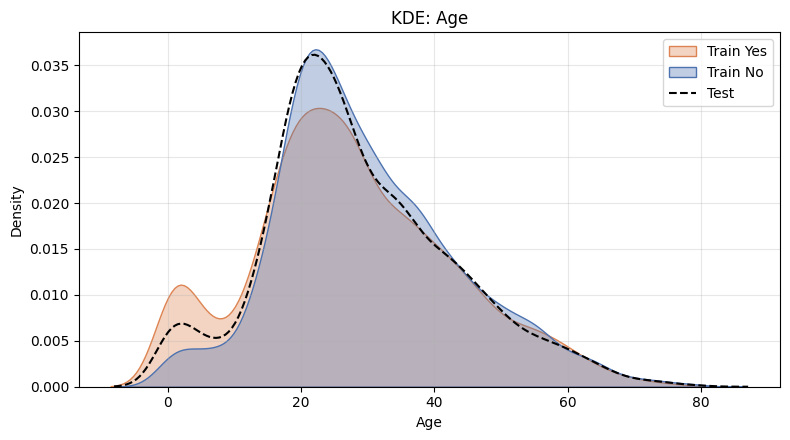

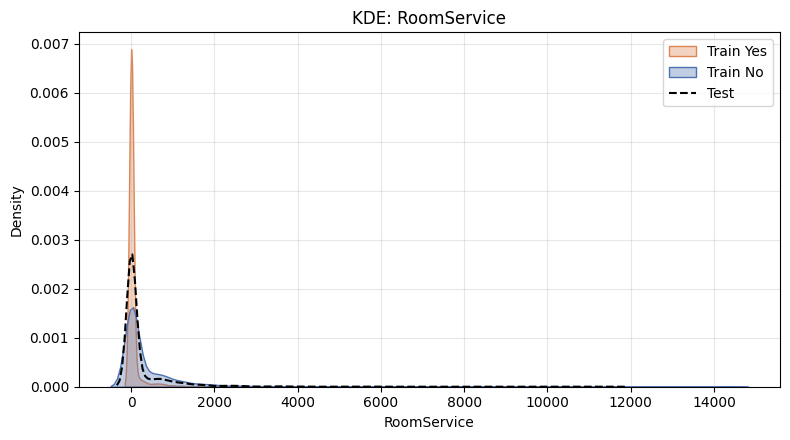

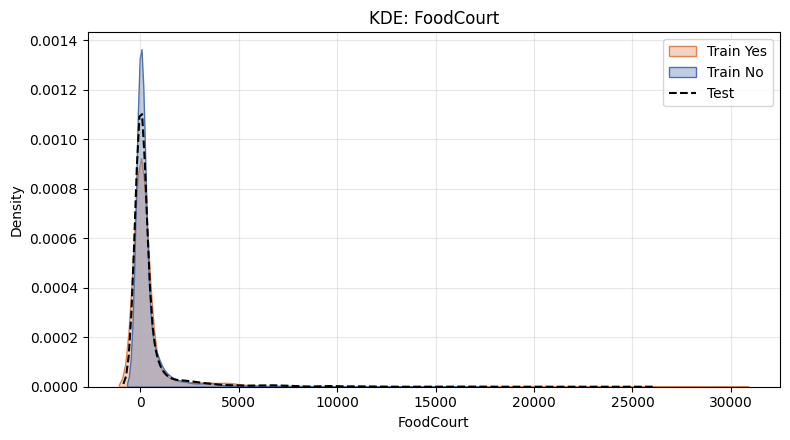

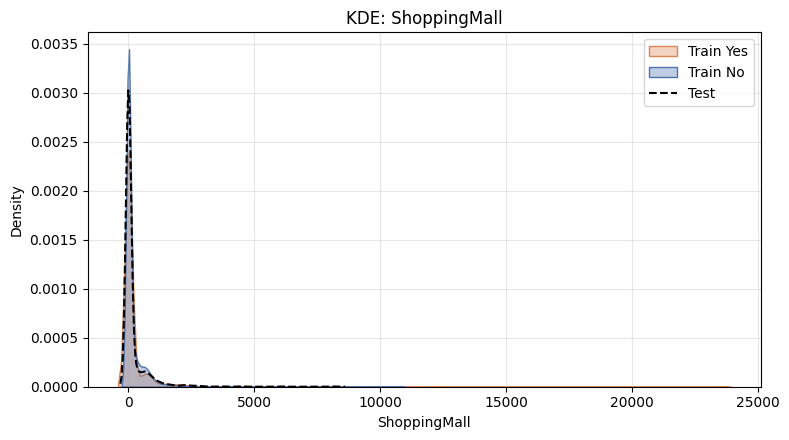

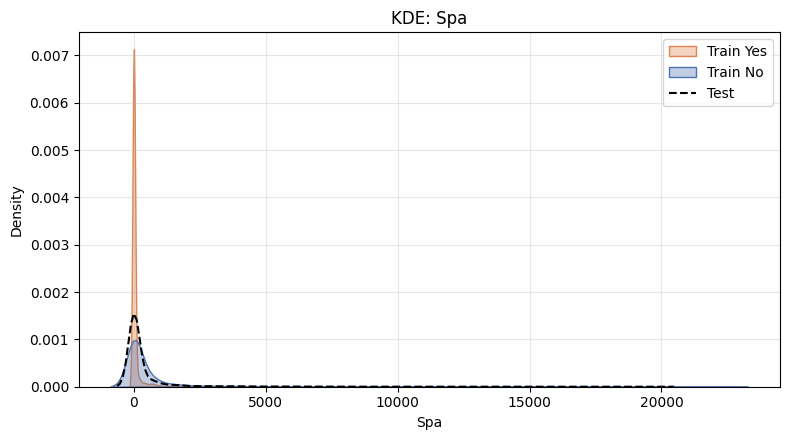

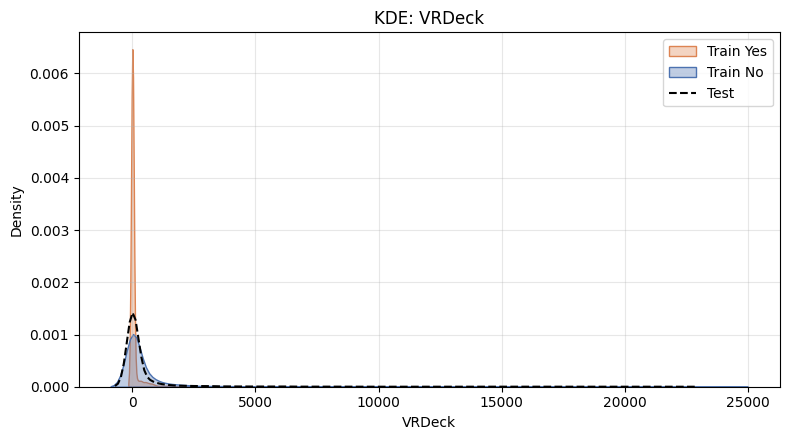

In [54]:
for c in num_cols:
    fig, ax = plt.subplots(figsize=(8, 4.5))
    sns.kdeplot(train.loc[train[TARGET] == 1, c], label="Train Yes",
                ax=ax, fill=True, alpha=0.35, color="#DD8452")
    sns.kdeplot(train.loc[train[TARGET] == 0, c], label="Train No",
                ax=ax, fill=True, alpha=0.35, color="#4C72B0")
    sns.kdeplot(test[c], label="Test", ax=ax, color="black", ls="--")
    ax.set_title(f"KDE: {c}")
    ax.set_xlabel(c)
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{PLOT_PATH}/kde_{c}.png", dpi=110, bbox_inches="tight")
    plt.show()
    plt.close(fig)

# UNIFIED SIGNAL TABLE

     feature type  mutual_info  pearson  rank_biserial  cramers_v
   CryoSleep  cat       0.1136      NaN            NaN     0.4684
         Spa  num       0.0723  -0.2211         0.3739        NaN
 RoomService  num       0.0682  -0.2446         0.3633        NaN
ShoppingMall  num       0.0653   0.0101         0.2231        NaN
      VRDeck  num       0.0628  -0.2071         0.3477        NaN
   FoodCourt  num       0.0400   0.0466         0.1855        NaN
        Deck  cat       0.0232      NaN            NaN     0.2149
  HomePlanet  cat       0.0189      NaN            NaN     0.1956
         Age  num       0.0103  -0.0750         0.0820        NaN
 Destination  cat       0.0062      NaN            NaN     0.1118
        Side  cat       0.0053      NaN            NaN     0.1035
         VIP  cat       0.0007      NaN            NaN     0.0369


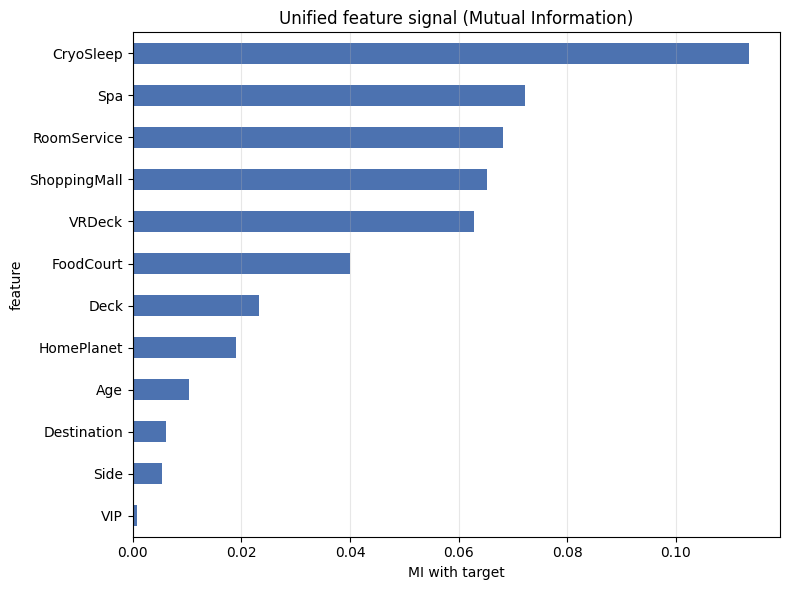

In [55]:
pearson = train[num_cols + [TARGET]].corr()[TARGET].drop(TARGET)

rows = []
for c in num_cols + cat_cols:
    if c in num_cols:
        pear = pearson.get(c, np.nan)
        mw = mw_df.set_index("feature").loc[c, "rank_biserial"] if c in mw_df["feature"].values else np.nan
        cram = np.nan
    else:
        pear = np.nan
        mw = np.nan
        cram = chi_df.set_index("feature").loc[c, "cramers_v"] if c in chi_df["feature"].values else np.nan
    rows.append({
        "feature": c,
        "type": "num" if c in num_cols else "cat",
        "mutual_info": mi_series.get(c, np.nan),
        "pearson": pear,
        "rank_biserial": mw,
        "cramers_v": cram,
    })

signal = pd.DataFrame(rows).sort_values("mutual_info", ascending=False)
print(signal.round(4).to_string(index=False))
signal.to_csv(f"{PLOT_PATH}/signal_summary.csv", index=False)

# Bar chart of MI for a visual
fig, ax = plt.subplots(figsize=(8, 6))
signal.set_index("feature")["mutual_info"].plot.barh(ax=ax, color="#4C72B0")
ax.invert_yaxis()
ax.set_title("Unified feature signal (Mutual Information)")
ax.set_xlabel("MI with target")
ax.grid(alpha=0.3, axis="x")
plt.tight_layout()
plt.savefig(f"{PLOT_PATH}/signal_summary.png", dpi=120, bbox_inches="tight")
plt.show()
plt.close()